In [1]:
import glob
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.integrate
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.wcs import WCS
from regions import CircleSkyRegion, CirclePixelRegion, RectangleSkyRegion, RectanglePixelRegion
from pandarallel import pandarallel
#from pysynphot import observation, spectrum
from matplotlib.colors import LogNorm
from sklearn.metrics import mean_squared_error
from matplotlib.backends.backend_pdf import PdfPages
from math import log
from astropy.constants import c as c_vel

# Initialize pandarallel with the progress bar.
pandarallel.initialize(progress_bar=True)


INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:

def extraer_datos_fits(archivo):
    """
    Extrae informacion de un LAMOST FITS.

    Parámetros:
    - archivo (str): Ruta al archivo FITS.

    Retorna:
    - dict: Diccionario con los valores extraídos del encabezado y los datos de flujo y longitud de onda.
    """
    with fits.open(archivo) as image:
        # Extraer valores del encabezado
        snrg = image[0].header["SNRG"]
        ra_obs = image[0].header["RA_OBS"]
        dec_obs = image[0].header["DEC_OBS"]
        desig = image[0].header["DESIG"]
        helio = image[0].header["HELIO"]
        vacuum = image[0].header["VACUUM"]
        fib_mask = image[0].header["FIB_MASK"]
        helio_rv = image[0].header["HELIO_RV"]
        
        # Crear y retornar el diccionario con los datos extraídos
        return snrg, ra_obs,dec_obs, desig, helio,vacuum,fib_mask, helio_rv,image



In [3]:
# Función para convertir si es necesario a little-endian ("<")
def convert_to_little_endian(arr):
    # Si el array ya es little-endian, lo retornamos sin cambios
    if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
        return arr
    # De lo contrario, cambiamos el orden de los bytes
    else:
        return arr.byteswap().newbyteorder('<')

In [4]:
def normalize_spectra(wlen, flux,ivar,grado,range):
    flux_new = convert_to_little_endian(flux)
    lambda_new = convert_to_little_endian(wlen)
    ivar_new = convert_to_little_endian(ivar)
    if np.mean(lambda_new) <1000:
        lambda_new = 10 * lambda_new
    df_spec = pd.DataFrame({"lambda": lambda_new, "flux": flux_new,"ivar":ivar_new})
    df_spec = interpolar_ceros_flux_optimizado(df_spec)
    df_spec = df_spec.loc[(df_spec["lambda"]>=range[0])&(df_spec["lambda"]<=range[1])]
    df_spec["e_flux"] = np.sqrt(1/df_spec["ivar"])
    df_spec_complete = df_spec.copy()
    bins =  50
    df_spec["bins"] = pd.cut(df_spec["lambda"], bins=bins)
    df_spec['flux_std'] = df_spec.groupby("bins", observed=False)["flux"].transform('std')
    df_spec = df_spec.loc[df_spec["flux_std"] < df_spec["flux_std"].quantile(0.7)].reset_index(drop=True)
    SNR = (df_spec["flux"] *np.sqrt(df_spec["ivar"])).median()
    coeffs = np.polyfit(df_spec["lambda"], df_spec["flux"], grado)
    poly_vals = np.polyval(coeffs, df_spec_complete["lambda"])
    df_spec_complete["flux_norm"] = df_spec_complete["flux"] /poly_vals
    df_spec_complete["e_flux_norm"] = df_spec_complete["e_flux"] /poly_vals
    return df_spec_complete, SNR

In [5]:

def idl_tabulated(x, f, p=5):
    """Calcula la integral de los datos tabulados (x, f) usando el método de Newton-Cotes.
    
    Parámetros:
    - x: Array de NumPy con las coordenadas x de los datos.
    - f: Array de NumPy con las coordenadas f (función) de los datos.
    - p: Número de puntos a usar en cada segmento de Newton-Cotes.
    
    Retorna:
    - La integral calculada de los datos.
    """
    
    def newton_cotes_segmento(x_segmento, f_segmento):
        """Calcula la integral de un segmento usando el método de Newton-Cotes."""
        # Si el segmento tiene menos de 2 puntos, no se puede calcular una integral.
        if x_segmento.shape[0] < 2:
            return 0
        
        # Calcula los rangos normalizados para los pesos de Newton-Cotes.
        rangos_normalizados = (x_segmento.shape[0] - 1) * (x_segmento - x_segmento[0]) / (x_segmento[-1] - x_segmento[0])
        
        # Obtiene los pesos de Newton-Cotes para el segmento.
        pesos = scipy.integrate.newton_cotes(rangos_normalizados)[0]
        
        # Calcula la integral del segmento.
        integral_segmento = (x_segmento[-1] - x_segmento[0]) / (x_segmento.shape[0] - 1) * np.dot(pesos, f_segmento)
        
        return integral_segmento
    
    # Inicializa el resultado total de la integral.
    integral_total = 0
    
    # Itera a través de los segmentos de los datos.
    for idx in range(0, x.shape[0], p - 1):
        # Calcula la integral del segmento actual y la suma al total.
        integral_total += newton_cotes_segmento(x[idx:idx + p], f[idx:idx + p])
    
    # Retorna la integral total calculada.
    return integral_total


In [6]:
#Funcion que crea una gaussiana
def Gauss(x, a, x0, sigma, b):
    return (a * np.exp(-(x - x0)**2 / (2 * sigma**2))) + b

In [7]:
def plot_group(df, group_id, ax,result_type):
    df_var = df.loc[(df["GroupID"].notna()) & (df["GroupID"] == group_id)]
    radius_arcsec = 5
    ancho_rectangulo = 5
    design = df_var["DESIG"].values
    center_sky = SkyCoord(df_var["ra"].iloc[0], df_var["dec"].iloc[0], unit='deg', frame='icrs')
    pm_ra, pm_dec = df_var["pmra"].iloc[0], df_var["pmdec"].iloc[0]
    region_sky_circle = CircleSkyRegion(center=center_sky, radius=radius_arcsec * u.arcsec)
    estrellas = SkyCoord(ra=df_var["RA_OBS"].values * u.deg, dec=df_var["DEC_OBS"].values * u.deg, frame='icrs')

    region_sky_rectangle = RectangleSkyRegion(center=center_sky,
                                               width=ancho_rectangulo * u.arcsec, height=ancho_rectangulo*radius_arcsec * u.arcsec,
                                               angle=(90*u.deg).to(u.rad) + np.arctan((pm_dec/pm_ra)) * u.rad)
    wcs = WCS(naxis=2)
    wcs.wcs.crval = [center_sky.ra.degree, center_sky.dec.degree]
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    
    if result_type=="table":
        comp_region = region_sky_circle.intersection(region_sky_rectangle)
        constain = comp_region.contains(estrellas,wcs)
        df_var.loc[constain,"constain"] = 1
        df_var.loc[df_var["constain"].isna(),"constain"] = 0
        index_selected = df_var.loc[df_var["constain"]==1].index
        index_no_selected = df_var.loc[df_var["constain"]==0].index
        df.loc[index_selected,"constain"] = 1
        df.loc[index_no_selected,"constain"] = 0
        return
    
    if result_type=="plot":    
        pixel_ra_dec = wcs.world_to_pixel(estrellas)
        region_pixel_circle = region_sky_circle.to_pixel(wcs)
        region_pixel_rectangle = region_sky_rectangle.to_pixel(wcs)
    
        unique_designs = np.unique(design)
        colors = plt.cm.jet(np.linspace(0, 1, len(unique_designs)))
        
        # Dibuja el círculo
        region_pixel_circle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
        
        region_pixel_rectangle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2,
                         label='Rectangle')
        
        # Crea diccionarios para mapear cada diseño único a un color y controlar las leyendas añadidas
        design_color_map = dict(zip(unique_designs, colors))
        added_legends = set()
    
        # Dibuja los puntos con etiquetas y colores correspondientes de 'design'
        for i, (ra, dec) in enumerate(zip(pixel_ra_dec[0], pixel_ra_dec[1])):
            design_i = design[i]
            color_i = design_color_map[design_i]
            
            if design_i not in added_legends:
                ax.plot(ra, dec, "o", color=color_i, label=design_i)
                added_legends.add(design_i)
            else:
                ax.plot(ra, dec, "o", color=color_i)
        
        # Punto extra con etiqueta en la leyenda
        ax.plot(-1, -1, "x", color='black', linestyle='None', label='Center')
        ax.plot([-1,-1+(pm_ra*100)],[-1,-1+(pm_dec*100)])
        # Ajustes de los límites del eje
        ax.set_xlim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, (radius_arcsec * u.arcsec).to(u.deg).value - 1)
        ax.set_ylim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, +(radius_arcsec * u.arcsec).to(u.deg).value - 1)
        return

In [8]:
def plot_group_unique(df,source_id, ax,result_type):
    df_var = df.loc[(df["source_id"]==source_id)]
    radius_arcsec = 5
    ancho_rectangulo = 5
    design = df_var["DESIG"].values
    center_sky = SkyCoord(df_var["ra"].iloc[0], df_var["dec"].iloc[0], unit='deg', frame='icrs')
    pm_ra, pm_dec = df_var["pmra"].iloc[0], df_var["pmdec"].iloc[0]
    region_sky_circle = CircleSkyRegion(center=center_sky, radius=radius_arcsec * u.arcsec)
    estrellas = SkyCoord(ra=df_var["RA_OBS"].values * u.deg, dec=df_var["DEC_OBS"].values * u.deg, frame='icrs')

    region_sky_rectangle = RectangleSkyRegion(center=center_sky,
                                               width=ancho_rectangulo * u.arcsec, height=ancho_rectangulo*radius_arcsec * u.arcsec,
                                               angle=(90*u.deg).to(u.rad) + np.arctan((pm_dec/pm_ra)) * u.rad)
    wcs = WCS(naxis=2)
    wcs.wcs.crval = [center_sky.ra.degree, center_sky.dec.degree]
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    
    if result_type=="table":
        comp_region = region_sky_circle.intersection(region_sky_rectangle)
        constain = comp_region.contains(estrellas,wcs)
        df_var.loc[constain,"constain"] = 1
        df_var.loc[df_var["constain"].isna(),"constain"] = 0
        index_selected = df_var.loc[df_var["constain"]==1].index
        index_no_selected = df_var.loc[df_var["constain"]==0].index
        df.loc[index_selected,"constain"] = 1
        df.loc[index_no_selected,"constain"] = 0
        return
    
    if result_type=="plot":    
        pixel_ra_dec = wcs.world_to_pixel(estrellas)
        region_pixel_circle = region_sky_circle.to_pixel(wcs)
        region_pixel_rectangle = region_sky_rectangle.to_pixel(wcs)
    
        unique_designs = np.unique(design)
        colors = plt.cm.jet(np.linspace(0, 1, len(unique_designs)))
        
        # Dibuja el círculo
        region_pixel_circle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
        
        region_pixel_rectangle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2,
                         label='Rectangle')
        
        # Crea diccionarios para mapear cada diseño único a un color y controlar las leyendas añadidas
        design_color_map = dict(zip(unique_designs, colors))
        added_legends = set()
    
        # Dibuja los puntos con etiquetas y colores correspondientes de 'design'
        for i, (ra, dec) in enumerate(zip(pixel_ra_dec[0], pixel_ra_dec[1])):
            design_i = design[i]
            color_i = design_color_map[design_i]
            
            if design_i not in added_legends:
                ax.plot(ra, dec, "o", color=color_i, label=design_i)
                added_legends.add(design_i)
            else:
                ax.plot(ra, dec, "o", color=color_i)
        
        # Punto extra con etiqueta en la leyenda
        ax.plot(-1, -1, "x", color='black', linestyle='None', label='Center')
        ax.plot([-1,-1+(pm_ra*100)],[-1,-1+(pm_dec*100)])
        # Ajustes de los límites del eje
        ax.set_xlim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, (radius_arcsec * u.arcsec).to(u.deg).value - 1)
        ax.set_ylim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, +(radius_arcsec * u.arcsec).to(u.deg).value - 1)
        return

In [9]:
def crear_espectro_con_gaussianas(pos1, sigma1, amplitud1, pos2, sigma2, amplitud2, SN, size=40):
    """
    Genera un espectro con dos gaussianas superpuestas sobre un fondo de ruido.

    Parámetros:
    pos1 (float): Posición (media) de la primera gaussiana.
    sigma1 (float): Desviación estándar de la primera gaussiana.
    amplitud1 (float): Amplitud de la primera gaussiana.
    pos2 (float): Posición (media) de la segunda gaussiana.
    sigma2 (float): Desviación estándar de la segunda gaussiana.
    amplitud2 (float): Amplitud de la segunda gaussiana.
    ruido_fondo (float): Nivel de ruido de fondo.
    size (int): Resolución del espectro.

    Retorna:
    np.array: El espectro resultante con las gaussianas y el ruido de fondo.
    """
    ruido_fondo = 1/SN
    # Crear el espectro base (fondo de ruido)
    espectro = np.random.normal(1, ruido_fondo, size)
    
    # Generar los puntos x del espectro
    x = np.linspace(4400, 4600, size)
    
    # Añadir las gaussianas al espectro
    gaussiana1 = amplitud1 * np.exp(-(x-pos1)**2 / (2*sigma1**2))
    gaussiana2 = amplitud2 * np.exp(-(x-pos2)**2 / (2*sigma2**2))
    
    espectro += gaussiana1 + gaussiana2
    
    return x, espectro

In [10]:
def calcular_delta_lambda(lambda_0_angstrom, v_km_s, i):
    """
    Calcula el ensanchamiento de la línea espectral debido a la rotación de una estrella,
    con longitud de onda en angstroms y velocidad en km/s.
    
    Parámetros:
    - lambda_0_angstrom: Longitud de onda de la línea espectral sin ensanchar (en angstroms).
    - v_km_s: Velocidad lineal en el ecuador de la estrella (en km/s).
    - i: Ángulo de inclinación del eje de rotación de la estrella con respecto a la línea de visión (en grados).
    
    Retorna:
    - Delta lambda: El ensanchamiento de la línea espectral (en angstroms).
    """
    c = 299792.458 * u.km.to(u.m)*u.m/u.second  # Velocidad de la luz en km/s
    i_rad = np.radians(i)  # Convertir inclinación a radianes
    
    # Convertir longitud de onda de angstroms a metros para el cálculo
    lambda_0_metros = lambda_0_angstrom * u.angstrom.to(u.m) * u.m

    v_km_s = v_km_s*u.km.to(u.m) *u.m / u.second

    # Calcular delta lambda en metros
    delta_lambda_metros = lambda_0_metros * (v_km_s/c) * np.sin(i_rad)
    
    # Convertir delta lambda de metros a angstroms para el resultado
 
    
    return delta_lambda_metros.to(u.Angstrom)

In [11]:
def interpolar_ceros_flux_optimizado(df):
    """
    Optimiza la interpolación lineal de los valores de 'flux' que son cero en el DataFrame dado,
    utilizando operaciones vectorizadas en lugar de bucles.
    
    Parámetros:
    - df (pandas.DataFrame): DataFrame con las columnas 'wave' y 'flux'.
    
    Retorna:
    - df (pandas.DataFrame): DataFrame con los valores de 'flux' cero reemplazados por valores interpolados.
    """
    # Marcar los ceros con NaN para usar la interpolación de pandas
    df.loc[df['flux'] == 0, 'flux'] = np.nan

    # Interpolar linealmente los NaNs
    df['flux'] = df['flux'].interpolate(method='linear')

    return df

In [12]:
def open_fits(file_name):
    data = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/sp_not_searched/"
  #  image = fits.open(f"/home/nicolas/nico/Data/LAMOST_sp_data_V2/{file_name}")
    image = fits.open(f"{data}{file_name}")    
    flux,ivar,wave,andmask,ormask,norm = image[1].data[0]
    return flux,ivar,wave,andmask,ormask,norm

In [13]:
def Detect_line_static_and_var(filename,rv,sp,blue_cont,red_cont,spec_line,lambda_peak,threshold,ax=None,plot=False):

    flux,ivar,wave,andmask,ormask,norm = open_fits(filename)
    spectra,snr = normalize_spectra(wave, flux, ivar, 1, [4000,5000])
    
    spectra["lambda"] = spectra["lambda"] + (rv*u.km/u.s*spectra["lambda"])/c_vel

    

    spectra = spectra.loc[(spectra["lambda"]>blue_cont[0])&
                                  (spectra["lambda"]<red_cont[1])]

    df_blue_red_region = spectra.loc[
        ((spectra["lambda"] > blue_cont[0]) & (spectra["lambda"] < blue_cont[1])) |
        ((spectra["lambda"] > red_cont[0]) & (spectra["lambda"] < red_cont[1]))
    ]
            
    sp_out_line = spectra.loc[
        ((spectra["lambda"] > blue_cont[0]) & (spectra["lambda"] < spec_line[0])) |
        ((spectra["lambda"] > spec_line[1]) & (spectra["lambda"] < red_cont[1]))
    ]


    slope_1, intercept_1, r_value_1, p_value_1, std_err_1 = stats.linregress(df_blue_red_region["lambda"], df_blue_red_region["flux"])
    fit_1 = slope_1 * sp_out_line["lambda"] + intercept_1 
    sp_out_line["flux-cont_1"] = sp_out_line["flux"] - fit_1
    dispersion_1 = sp_out_line["flux-cont_1"].std()
    df_top_bot = sp_out_line.loc[np.absolute(sp_out_line["flux-cont_1"])<dispersion_1]


    slope_3, intercept_3, r_value_3, p_value_3, std_err_3 = stats.linregress(df_top_bot["lambda"], df_top_bot["flux"])
    fit_3 = slope_3 * sp_out_line["lambda"] + intercept_3
    dispersion_third_fit = np.std(np.absolute(df_top_bot["flux"] - fit_3))

    spectra["third_cont"] = np.polyval([slope_3,intercept_3], spectra["lambda"])
    spectra["flux_norm_line"] = spectra["flux"] /spectra["third_cont"]
    df_line = spectra.loc[(spectra["lambda"]>spec_line[0])&
                      (spectra["lambda"]<spec_line[1])].reset_index(drop=True)


    df_line["flux-cont"] = np.absolute(df_line["flux"] - df_line["third_cont"])
    abs_flux_cont_q = df_line.loc[(df_line["lambda"]>lambda_peak-3)&
                                    (df_line["lambda"]<lambda_peak+3)]["flux-cont"].quantile(0.95)
    
    df_line_over_q = df_line.loc[(df_line["flux-cont"]>abs_flux_cont_q)&
                                    (df_line["lambda"]>lambda_peak-3)&
                                    (df_line["lambda"]<lambda_peak+3)].reset_index(drop=True)
    if (df_line_over_q["flux-cont"] >  threshold*dispersion_third_fit).any():
        detection = "E"
        if (df_line_over_q["flux"] > df_line_over_q["third_cont"]).any():
            line_type = "ems"
        else:
            line_type = "abs"
    else:
        line_type="U"
    upper_limit = df_line["third_cont"] + threshold*dispersion_third_fit
    lower_limit  = df_line["third_cont"] - threshold*dispersion_third_fit        
    if plot==True:        
        ax.plot(spectra["lambda"], spectra["flux"], "o-", c="grey", alpha=0.5)
        ax.plot(df_line["lambda"],df_line["flux"], "o-",color='black')
        ax.scatter(df_blue_red_region["lambda"], df_blue_red_region["flux"] , marker='o', facecolors='none',s=30, edgecolors='r')

        ax.scatter(df_top_bot["lambda"], df_top_bot["flux"], s=20, marker='o', 
           facecolors='red', edgecolors='none', c="red", zorder=10)

        ax.plot(sp_out_line["lambda"], fit_1,label="Reference continuum", linestyle='dotted', c="red")
        ax.plot(sp_out_line["lambda"], fit_3, label="Final local continuum", linestyle='--', c="blue")
        ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
        ax.axvline(x=lambda_peak, color='purple', linestyle='--', label=f'$\lambda${int(lambda_peak)}')
        ax.set_xlabel(r'Lambda ($\AA$)')
        ax.set_ylabel('Flux')
        ax.set_yscale('log')
       # ax.yaxis.set_major_formatter(LogFormatterExponent(base=10))
        #ax.set_title(f"{line_type}[{sp}]")            
        ax.plot(df_line_over_q["lambda"], df_line_over_q["flux"], "o", c="purple", label="Spectra Line Q$_{95}$")
        ax.legend(fontsize=9)
        plt.savefig("Detection Line.pdf", format='pdf', bbox_inches='tight')
      #  ax.set_ylim(spectra["flux"].min(), 1.03)
        return 
    else:
        coeffs = (slope_3,intercept_3)
        return spectra,coeffs, line_type

<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_8479/2869076881.py:68: SyntaxWarning: invalid escape sequence '\p'
  ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
/tmp/ipykernel_8479/2869076881.py:68: SyntaxWarning: invalid escape sequence '\s'
  ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
/tmp/ipykernel_8479/2869076881.py:69: SyntaxWarning: invalid escape sequence '\l'
  ax.axvline(x=lambda_peak, color='purple', linestyle='--', label=f'$\lambda${int(lambda_peak)}')


In [14]:
def gauss(x, A, x0, sigma,b):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + b

def stimate_parameters_line_type(lambda_peak,cota_mean,df_continuo,line_type):
    if line_type=="abs":
        A_1 = df_continuo.loc[(df_continuo["lambda"]> lambda_peak -cota_mean) & (df_continuo["lambda"] <lambda_peak + cota_mean)]["flux_norm_line"].min() -  df_continuo["flux_norm_line"].mean()
        amplitude_1 = -(1-A_1)
        A_lim_inf = -np.inf
        A_lim_sup = 0
    if line_type=="ems":
        A_1 = df_continuo.loc[(df_continuo["lambda"]> lambda_peak -cota_mean) & (df_continuo["lambda"] <lambda_peak + cota_mean)]["flux_norm_line"].max() -  df_continuo["flux_norm_line"].mean()
        amplitude_1 = A_1
        A_lim_inf = 0
        A_lim_sup = np.inf  
    return amplitude_1,A_lim_sup,A_lim_inf








In [15]:
def main_function(filename,
                    rv,
                    sp,
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,
                    ax=None,
                    plot=False
                ):
    
    try:
        spectra,coeffs,line_type_1 = Detect_line_static_and_var(filename,
                        rv,
                        sp,  
                        blue_cont,
                        red_cont,
                        spec_line,
                        lambda_peak,
                        threshold,plot=False)

        linea_1 = lines[key]["central_lambda"]
        linea_2 = None
        if linea_1 == 4481:
            linea_2 =  4471
        if linea_1 == 4471:
            linea_2 = 4481
        if linea_1 ==4650:
            linea_2 = 4640 #NIII
        if linea_1 == 4088:
            linea_2 = 4102 #H delta
        if linea_1 ==4121:
            linea_2 =4102 # H delta
        if linea_1 == 4200:
            linea_2 = 4189 # OII
        if linea_1 == 4387:
            linea_2 = 4380 # NII
        if linea_1 ==4553:
            linea_2 = 4541 # He I

        if line_type_1!="U":
            line_type_1,EW4,fitting = ajuste_gaussiano(spectra,linea_1,linea_2,line_type_1,coeffs,spec_line,3,1300,sp)
        else:
            EW4= np.nan
            fitting = "U"
        return EW4, line_type_1, fitting
    except:
        return "error","error","error"

In [16]:
def main_HeIMgII(filename,
                    sp,
                     rv,
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,
                    ax=None,
                    plot=False
                ):

    spectra,coeffs,line_type_1 = Detect_line_static_and_var(filename,
                    rv,
                    sp,  
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,plot=False)
    
    linea_1 = 4471
    linea_2 = 4481
    if line_type_1!="U":
        EW_line1,EW_line2 = ajuste_HeIMgII(spectra,linea_1,linea_2,line_type_1,coeffs,spec_line,3,1300,sp)
    else:
        EW_line1,EW_line2 = np.nan,np.nan
    return EW_line1,EW_line2

In [17]:
def Characterize_Hgamma(filename,lambda_mean,R,rango_linea):
    try:
        flux,ivar,wave,andmask,ormask,norm = open_fits(filename)
        df,snr = normalize_spectra(wave, flux, ivar, 1, [4000,5000])
        df_continuo = df.loc[(df["lambda"] > rango_linea[0]) & (df["lambda"] < rango_linea[1])]
        cota_mean = np.sqrt((lambda_mean/(R*2.634))**2 + 4**2)
        sigma = lambda_mean/(R*2.634)
        b = df_continuo["flux_norm"].quantile(0.9)
        absorcion = df_continuo["flux_norm"].min() -  df_continuo["flux_norm"].mean()
        emision = df_continuo["flux_norm"].max() -  df_continuo["flux_norm"].mean()
        if np.absolute(absorcion) > np.absolute(emision):
            amplitude = -(1-absorcion)
        else:
            amplitude = emision


        p_predicted, p_cov = curve_fit(Gauss,
                                   df_continuo["lambda"].values,
                                   df_continuo["flux_norm"].values,
                                   p0=[amplitude, lambda_mean, sigma, b],
                                   bounds=([-10, lambda_mean-cota_mean, sigma, 0], [10, lambda_mean+cota_mean, np.inf, 3]))
        f_gauss = Gauss(np.linspace(df_continuo["lambda"].min(),df_continuo["lambda"].max(),1000), *p_predicted)
        errors = np.sqrt(np.diag(p_cov))
        error_A, error_mean, error_sigma, error_B = errors
        lambda_peak = 4341.69
        df_linea = df.loc[(df["lambda"] > 4341.69 -25) &
                            (df["lambda"] < 4341.69 +25)].reset_index(drop=True)

        lambda_empirico = (df_linea['lambda'] * df_linea['flux']).sum() / df_linea['flux'].sum()

        plt.plot(df_continuo["lambda"],df_continuo["flux_norm"],"o-")
        plt.plot(np.linspace(df_continuo["lambda"].min(),df_continuo["lambda"].max(),1000),f_gauss,label="Gauss Fit")
        plt.axvline(x=lambda_empirico,c="red",label="Empirical lambda_0")
        plt.axvline(x=4341.69 -22,c="green",label="Line Inf")
        plt.axvline(x=4341.69 +22,c="green",label="Line Sup")
        plt.legend()
        plt.show()
        return p_predicted[1], lambda_empirico,snr#, chi2, std_continuo
    except:
        return "error","error","error"

In [18]:
def gauss(x, A, x0, sigma,b):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + b

def dos_gaussianas(x, A1, x01, sigma1, A2, x02, sigma2, b):
    return gauss(x, A1, x01, sigma1,b/2) + gauss(x, A2, x02, sigma2,b/2)

def calculate_bic(n, mse, num_params):
    bic = n * log(mse) + num_params * log(n)
    return bic

def gauss_core_emission(x, A1, x01, sigma1, b1, A2, sigma2):
    # Primera gaussiana (puede ser emisión o absorción dependiendo del signo de A1)
    gaussian_first = gauss(x, A1, x01, sigma1, b1)
    # Segunda gaussiana (siempre en emisión y centrada en el pico de la primera)
    gaussian_second = gauss(x, A2, x01, sigma2, 0)  # b2 es cero para que solo ajuste el pico
    # Combina las dos gaussianas
    return gaussian_first + gaussian_second

def ajuste_gaussiano(df_continuo,lambda_peak_1,lambda_peak_2,line_type,coeffs,spec_line,cota_mean,R,sp,plot=False,ax=None):
    # Extraer datos
    x_datos = df_continuo["lambda"].values
    y_datos = df_continuo["flux_norm_line"].values
    # Valores iniciales para los parámetros del ajuste
    sigma = lambda_peak_1/(R*2.634)
    b = df_continuo["flux_norm_line"].quantile(0.9)
    EW4_g2 = 1
    ##AJUSTE UNA GAUSSIANA

    amplitude_1,A_lim_sup_1,A_lim_inf_1 = stimate_parameters_line_type(lambda_peak_1,3,df_continuo,line_type)
    p0_simple = [amplitude_1, lambda_peak_1, sigma, b]
    bounds_simple = ([A_lim_inf_1, lambda_peak_1-cota_mean, sigma, 0], [A_lim_sup_1, lambda_peak_1+cota_mean,np.inf, 1.5])
    # Ajuste de una sola gaussiana
    try:
        p_opt_simple, p_cov_simple = curve_fit(gauss, x_datos, y_datos, p0=p0_simple, bounds=bounds_simple, max_nfev=10000)
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :
            line_type_1 = "U"
            EW4 = np.nan   
            return line_type,EW4,"U"
    df_linea = df_continuo.loc[(df_continuo["lambda"]> p_opt_simple[1] - 4*p_opt_simple[2]) & (df_continuo["lambda"]< p_opt_simple[1] + 4*p_opt_simple[2])]
    x_linea,y_linea = df_linea["lambda"].values,df_linea["flux"].values
    mse_simple = mean_squared_error(y_linea,  gauss(x_linea, *p_opt_simple))
    bic_simple = calculate_bic(len(y_linea), mse_simple, len(p_opt_simple))    
    # AJUSTE DOS GAUSSIANAS
    if lambda_peak_2 != None :
        delta_lambda = p_opt_simple[1] - lambda_peak_1
        lambda_peak_2 = lambda_peak_2+delta_lambda
        amplitude_2,A_lim_sup_2,A_lim_inf_2 = stimate_parameters_line_type(lambda_peak_2,3,df_continuo,line_type) 
        p0_doble = [amplitude_1,lambda_peak_1, sigma, amplitude_2, lambda_peak_2, sigma, b]
        bounds_doble = ([-np.inf, lambda_peak_1-cota_mean, sigma, -np.inf, lambda_peak_2-cota_mean, sigma, 0], 
                        [0, lambda_peak_1 + cota_mean, np.inf, 0, lambda_peak_2+cota_mean, np.inf,1.5])
        try:
            p_opt_doble, p_cov_doble = curve_fit(dos_gaussianas, x_datos, y_datos, p0=p0_doble, bounds=bounds_doble, max_nfev=10000)
            mse_doble = mean_squared_error(y_linea,  dos_gaussianas(x_linea, *p_opt_doble))
            bic_doble = calculate_bic(len(y_linea), mse_doble, len(p_opt_doble))
        except ValueError as e:
            if str(e) == "`x0` is infeasible." :
                bic_doble = -999
                p_opt_doble = [-999,-999,-999]    
    else:
        bic_doble = -999
        p_opt_doble = [-999,-999,-999]

    #AJUSTE CORE EMISION

    p0_core_emission = [p_opt_simple[0] , p_opt_simple[1], p_opt_simple[2] , p_opt_simple[-1],-amplitude_1/2,sigma]

    bounds_core_emission =     ([-np.inf, lambda_peak_1-cota_mean, sigma , 0, 0        ,sigma/2], 

                       [0 , lambda_peak_1+cota_mean, np.inf, 1.1, np.inf ,sigma])
    
    try:
        p_predicted_core_E, p_cov_core_E = curve_fit(gauss_core_emission, x_datos, y_datos, p0=p0_core_emission, bounds=bounds_core_emission, max_nfev=50000)
        mse_core_E = mean_squared_error(y_linea,  gauss_core_emission(x_linea, *p_predicted_core_E))
        bic_core_E = calculate_bic(len(y_linea), mse_core_E, len(p_predicted_core_E))
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :
            bic_core_E = -999
            p_predicted_core_E = [-999,-999,-999] 

    # MEJOR AJUSTE

    parameters =[p_opt_simple,p_opt_doble,p_predicted_core_E]
    gauss_func = [gauss,dos_gaussianas,gauss_core_emission]
    bic_values = [bic_simple,bic_doble,bic_core_E]
    names = ["Single Line","Blended Line", "Core Emission Line"]
    fitting = ["E","T", "E"]
    sigmas = [p_opt_simple[2],p_opt_doble[2],p_predicted_core_E[2]]
    p_lambda = [p_opt_simple[1],p_opt_doble[1],p_predicted_core_E[1]]
    idx = np.argmax(bic_values)

    # EW del mejor ajuste
    df_EW = df_continuo.loc[(df_continuo["lambda"]> p_lambda[idx] - 4*sigmas[idx]) &
                            (df_continuo["lambda"]< p_lambda[idx] + 4*sigmas[idx])].reset_index(drop=True)
    x_EW,y_EW = df_EW["lambda"].values,df_EW["flux"].values
    if (names[idx]== "Single Line") | (names[idx]== "Core Emission Line") :   
        continuo_linea =  coeffs[0] * x_EW + coeffs[1]
        EW4 =idl_tabulated(x_EW,1-(y_EW/continuo_linea))
    else:
        df_EW["gauss_1"] = gauss(x_EW, *np.concatenate((p_opt_doble[:3], p_opt_doble[-1]), axis=None))
        df_EW["gauss_2"] = gauss(x_EW, *p_opt_doble[3:])        
        EW4 = idl_tabulated(x_EW,1-(df_EW["gauss_1"].values))
        EW4_g2 =idl_tabulated(x_EW,1-(df_EW["gauss_2"].values))        
    if plot==True:
        ax.axvline(x=p_lambda[idx] - 4*sigmas[idx], color='r', linestyle='--',label="-4 Sigma Best Gauss")
        ax.axvline(x=p_lambda[idx] + 4*sigmas[idx], color='r', linestyle='--',label="+4 Sigma Best Gauss")
        ax.axvline(x=df_EW["lambda"].min(), color='r', linestyle='dotted',label="-4 Sigma First Gauss")
        ax.axvline(x=df_EW["lambda"].max(), color='r', linestyle='dotted',label="+4 Sigma First Gauss")
        ax.set_title(f"{line_type}[{sp}]")
        ax.set_title(f" {np.round(EW4,2)} {bic_simple} [{sp}]")
        if names[idx] == "Blended Line":
            ax.plot(df_continuo["lambda"],df_continuo["flux_norm_line"],"o-",c="grey")
            ax.plot(df_EW["lambda"],df_EW["flux_norm_line"],"o-",c="black")
            ax.plot(df_EW["lambda"],df_EW["gauss_1"],c="red",linestyle="--")
            ax.plot(df_EW["lambda"],df_EW["gauss_2"],c="blue",linestyle="--")
        else:
            ax.plot(df_continuo["lambda"],df_continuo["flux"],"o-",c="grey")
            ax.plot(df_EW["lambda"],df_EW["flux"],"o-",c="black")
            ax.plot(df_continuo["lambda"],coeffs[0] * df_continuo["lambda"] + coeffs[1],c="green")
        ax.legend()
        return

        
    return line_type,EW4, fitting[idx]

In [19]:
def ajuste_HeIMgII(df_continuo,lambda_peak_1,lambda_peak_2,line_type,coeffs,spec_line,cota_mean,R,sp,plot=False,ax=None):
    # Extraer datos
    x_datos = df_continuo["lambda"].values
    y_datos = df_continuo["flux_norm_line"].values
    # Valores iniciales para los parámetros del ajuste
    sigma = lambda_peak_1/(R*2.634)
    b = df_continuo["flux_norm_line"].quantile(0.9)
    ##AJUSTE UNA GAUSSIANA

    amplitude_1,A_lim_sup_1,A_lim_inf_1 = stimate_parameters_line_type(lambda_peak_1,3,df_continuo,line_type)
    p0_simple = [amplitude_1, lambda_peak_1, sigma, b]
    bounds_simple = ([A_lim_inf_1, lambda_peak_1-cota_mean, sigma, 0], [A_lim_sup_1, lambda_peak_1+cota_mean,np.inf, 1.5])
    # Ajuste de una sola gaussiana
    try:
        p_opt_simple, p_cov_simple = curve_fit(gauss, x_datos, y_datos, p0=p0_simple, bounds=bounds_simple, max_nfev=10000)
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :   
            return np.nan,np.nan
    df_linea = df_continuo.loc[(df_continuo["lambda"]> p_opt_simple[1] - 6*p_opt_simple[2]) & (df_continuo["lambda"]< p_opt_simple[1] + 6*p_opt_simple[2])]
    x_linea,y_linea = df_linea["lambda"].values,df_linea["flux"].values
    mse_simple = mean_squared_error(y_linea,  gauss(x_linea, *p_opt_simple))
    bic_simple = calculate_bic(len(y_linea), mse_simple, len(p_opt_simple))    
    # AJUSTE DOS GAUSSIANAS
    delta_lambda = p_opt_simple[1] - lambda_peak_1
    lambda_peak_2 = lambda_peak_2+delta_lambda
    amplitude_2,A_lim_sup_2,A_lim_inf_2 = stimate_parameters_line_type(lambda_peak_2,3,df_continuo,line_type) 
    p0_doble = [amplitude_1,lambda_peak_1, sigma, amplitude_2, lambda_peak_2, sigma, b]
    bounds_doble = ([-np.inf, lambda_peak_1-cota_mean, sigma, -np.inf, lambda_peak_2-cota_mean, sigma, 0], 
                    [0, lambda_peak_1 + cota_mean, np.inf, 0, lambda_peak_2+cota_mean, np.inf,1.5])
    try:
        p_opt_doble, p_cov_doble = curve_fit(dos_gaussianas, x_datos, y_datos, p0=p0_doble, bounds=bounds_doble, max_nfev=10000)
        mse_doble = mean_squared_error(y_linea,  dos_gaussianas(x_linea, *p_opt_doble))
        bic_doble = calculate_bic(len(y_linea), mse_doble, len(p_opt_doble))
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :   
            return np.nan,np.nan
        # EW del mejor ajuste
    df_EW = df_continuo.loc[(df_continuo["lambda"]> p0_doble[1] - 4*p0_doble[2]) &
                            (df_continuo["lambda"]< p0_doble[4] + 4*p0_doble[5])].reset_index(drop=True)
    x_EW,y_EW = df_EW["lambda"].values,df_EW["flux"].values

    df_EW["gauss_1"] = gauss(x_EW, *np.concatenate((p_opt_doble[:3], p_opt_doble[-1]), axis=None))
    df_EW["gauss_2"] = gauss(x_EW, *p_opt_doble[3:])        
    EW4 = idl_tabulated(x_EW,1-(df_EW["gauss_1"].values))
    EW4_g2 =idl_tabulated(x_EW,1-(df_EW["gauss_2"].values))        
    if plot==True:
        ax.axvline(x=p0_doble[1] - 4*p0_doble[2], color='r', linestyle='--',label="-4 Sigma Best Gauss")
        ax.axvline(x=p0_doble[4] + 4*p0_doble[5], color='r', linestyle='--',label="+4 Sigma Best Gauss")
        ax.axvline(x=df_EW["lambda"].min(), color='r', linestyle='dotted',label="-4 Sigma First Gauss")
        ax.axvline(x=df_EW["lambda"].max(), color='r', linestyle='dotted',label="+4 Sigma First Gauss")
        ax.plot(df_continuo["lambda"],df_continuo["flux_norm_line"],"o-",c="grey")
        ax.plot(df_EW["lambda"],df_EW["flux_norm_line"],"o-",c="black")
        ax.plot(df_EW["lambda"],df_EW["gauss_1"],c="red",linestyle="--")
        ax.plot(df_EW["lambda"],df_EW["gauss_2"],c="blue",linestyle="--")
        ax.legend()
        return

        
    return EW4,EW4_g2

In [20]:
def create_histogram(data1,data2, column, ax, data_labels=['Zari', 'Skiff'],
                     colors=['black', 'red'],cuts=True):
    # Asegúrate de que 'data_labels' tenga al menos 2 etiquetas
    if len(data_labels) < 2:
        raise ValueError("data_labels debe tener al menos dos etiquetas.")

    # Separar los datos en dos conjuntos
    data1 = data1[column]
    data2 = data2[column]

    # Calcular los bins
    bins = np.linspace(data1.min(),data1.max(), 50)

    # Dibujar los histogramas
    ax.hist(data1, bins=bins, alpha=0.5, color=colors[0], edgecolor='black', label=data_labels[0])
    ax.hist(data2, bins=bins, alpha=0.5, color=colors[1], edgecolor='black', label=data_labels[1])

    ks_test = stats.kstest(data1,data2)
    ks_test = np.round(ks_test[0],3)
    ax.set_title(f' K-S: {ks_test}')

    # Establecer la escala logarítmica en el eje y
    ax.set_yscale('log')
    
    lower_x = data1.quantile(0.000001)
    upper_x = data1.quantile(0.999999)
    ax.set_xlim(lower_x, upper_x)
    ax.set_xlabel(column)
    # Agregar líneas verticales para los límites
    if cuts ==True:
        lower_bound = data2.quantile(0.01)
        upper_bound = data2.quantile(0.99)
        ax.axvline(lower_bound, color='orange', linestyle='dashed', linewidth=2, label='Lower limit 1%')
        ax.axvline(upper_bound, color='purple', linestyle='dashed', linewidth=2, label='Upper limit 99%')
            # Añadir títulos y etiquetas
        return (lower_bound,upper_bound)
    else:
        return

In [21]:
path_plots = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/plots/"

## Search for counterpart in lamost
To download the spectra, we include stars that are part of the training and test sets; however, they are not incorporated into the final analysis or results. This approach is used to facilitate the archiving of the spectra.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv')
df_B2 = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv')

/tmp/ipykernel_36104/1822969700.py:1: DtypeWarning: Columns (50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv')
/tmp/ipykernel_36104/1822969700.py:2: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df_B2 = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv')


In [5]:
df_B2.keys()

Index(['index', 'source_id', 'ra', 'dec', 'ra_error', 'dec_error', 'Parallax',
       'Parallax_error', 'Parallax_over_error', 'pmRA', 'pmDEC', 'pmRA_error',
       'pmDEC_error', 'Gmag', 'BPmag', 'phot_g_n_obs',
       'phot_g_mean_flux_over_error', 'phot_rp_n_obs',
       'phot_rp_mean_flux_over_error', 'phot_bp_n_obs',
       'phot_bp_mean_flux_over_error', 'RPmag', 'ph_qual', 'tmass_oid', 'Jmag',
       'Hmag', 'Ksmag', 'j_ks_0', 'J-H', 'Sigma5d_max', 'Excess_noise',
       'visibility_periods_used', 'RUWE', 'Gof_al',
       'Ipd_gof_harmonic_amplitude', 'ipd_frac_odd_win', 'ipd_frac_multi_peak',
       'matched_transits_removed', 'astrometric_params_solved',
       'Excess_noise_sig', 'phot_variable_flag', 'skiff_type', 'Bibcode',
       'ra_skiff', 'dec_skiff', 'GroupID_skiff', 'GroupSize_skiff',
       'Sep_skiff', 'mk', 'Bibcode_list', 'index_list', 'skiff_type_list',
       'source_id_list', 'std_sp', 'label', 'Jmag-Hmag', 'Jmag-Ksmag',
       'Jmag-Gmag', 'Jmag-BPmag', 'Jmag-

In [14]:
df_B2.loc[(df_B2["B2_cut_probability"]>0.6)&(df_B2["B2_cut_split"].isna())]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-Gmag,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability
35469,57,6056404410010181888,193.446857,-60.372235,0.010233,0.011742,0.485992,0.016196,30.007717,-4.726398,...,-1.210121,-1.350078,-0.910345,-0.139957,0.299776,0.439733,0.299776,NaN,NaN,0.801667
35471,78,5548252295022221440,122.773256,-31.270177,0.010242,0.011390,0.223595,0.015097,14.810351,-2.691090,...,-0.139358,-0.181691,0.001466,-0.042333,0.140824,0.183157,0.140824,NaN,NaN,0.645000
35472,89,4067518953423901568,269.773997,-24.435101,0.015131,0.012173,0.336776,0.016081,20.942917,0.373542,...,-2.068145,-2.553498,-1.396665,-0.485353,0.671480,1.156833,0.671480,NaN,NaN,0.743333
35475,185,2182012333201634304,311.393040,51.550021,0.014557,0.015758,0.558750,0.017105,32.665325,-2.174443,...,-0.714410,-0.888800,-0.394564,-0.174390,0.319846,0.494236,0.319846,NaN,NaN,0.773333
35483,511,458308955066917120,35.298325,56.853907,0.013860,0.016497,0.388412,0.025166,15.433717,-0.632541,...,-0.457495,-0.520022,-0.196582,-0.062527,0.260912,0.323440,0.260912,NaN,NaN,0.943333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99380,1090707,5852268497137570304,208.378431,-64.470820,0.008772,0.009906,0.248054,0.014103,17.588459,-6.577054,...,-1.503648,-1.895254,-0.922230,-0.391606,0.581418,0.973024,0.581418,NaN,NaN,0.960833
99382,1090734,5337709802751076608,167.045154,-60.246386,0.013423,0.012417,0.607679,0.015017,40.466816,-6.604736,...,-1.309327,-1.580618,-0.834572,-0.271290,0.474756,0.746046,0.474756,NaN,NaN,0.764167
99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,0.352274,NaN,NaN,0.783333
99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,0.187722,NaN,NaN,0.907500


In [ ]:
16411

In [4]:
df = df.loc[df["B3"].isna()]

In [6]:
df = df.loc[(df["B3_cut_probability"]>0.6)]

In [7]:
df = df.merge(df_B2[['index','B2_cut_probability']],how="left",on="index")

In [8]:
df = df.loc[(df["B3_cut_probability"]>0.6)&(df['B2_cut_probability']<0.6)]

In [15]:
1468/9089

0.1615139179227638

In [47]:
df_for_lamost = df[["ra","dec"]]
df_for_lamost["sep"] = 5
df_for_lamost.to_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Candidates_Lamost_B3_not_searched.csv',
                     header=False,sep=",",index=False)

/tmp/ipykernel_626228/588543198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_lamost["sep"] = 5


## Create the dataframes information

In [22]:
path_data = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/sp_not_searched/*"
archivos = glob.glob(path_data, recursive=True)

In [23]:
# Inicializa el DataFrame con nombres de columnas.
df = pd.DataFrame(columns=['SNRG', 'RA_OBS','DEC_OBS', 'DESIG', 'HELIO','VACUUM', 'HELIO_RV', 'fits_name'])

for i in archivos:
    # Llama a la función y desempaqueta el resultado directamente en las variables.
    snrg, ra_obs,dec_obs, desig, helio,vacuum,fib_mask, helio_rv,image = extraer_datos_fits(i)
    
    # Extrae el nombre del archivo FITS.
    fits_name = i.split("/")[-1]
    
    # Crea un diccionario con los datos y el nombre del archivo.
    fila = {'SNRG': snrg, 'RA_OBS': ra_obs, 'DEC_OBS': dec_obs, 'DESIG': desig, 'HELIO': helio,'VACUUM':vacuum,"FIB_MASK":fib_mask, 'HELIO_RV': helio_rv, 'fits_name': fits_name}
    
    # Añade la fila al DataFrame.
    df = pd.concat([df,pd.DataFrame([fila])])


/tmp/ipykernel_636434/526399621.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,pd.DataFrame([fila])])


In [24]:
df.to_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/LAMOST_low_resolution_information_not_searched.csv",index=False)

## Check the pointing

In [2]:
import pandas as pd

In [75]:
df_xmatch = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/LAMOST_low_resolution_not_searched_Xmatch5arcsec.csv")


In [76]:
df_xmatch = df_xmatch.loc[df_xmatch["B3_cut_probability"]>0.6].reset_index(drop=True)

/tmp/ipykernel_636434/65292502.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.loc[constain,"constain"] = 1


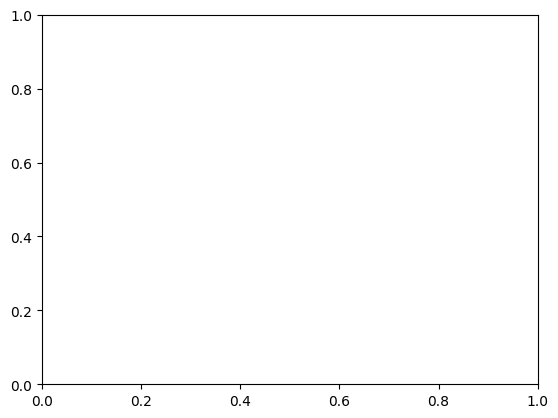

In [77]:
#topcat all matches all from 1 (the candidates catalog)
df_xmatch = df_xmatch.rename(columns={"pmRA":"pmra", "pmDEC":"pmdec","ra_1":"ra","dec_1":"dec"})
df_xmatch = df_xmatch.loc[df_xmatch["fits_name"].notna()].reset_index(drop=True)
Sources_no_uniques_5arcsec = len(df_xmatch.loc[df_xmatch["GroupID"].notna()])
Fuente_gaia_en_Groupid = (df_xmatch.loc[df_xmatch["GroupID"].notna()].groupby("GroupID")["source_id"].nunique() > 1).any()
source_con_mas_de_un_espectro = df_xmatch.loc[df_xmatch["GroupID"].notna()]["source_id"].nunique()
df_xmatch_unique = df_xmatch.loc[df_xmatch["GroupID"].isna()].reset_index(drop=True)
df_xmatch_repeated = df_xmatch.loc[df_xmatch["GroupID"].notna()].reset_index(drop=True)

fig, ax = plt.subplots()
for i in range(len(df_xmatch_repeated)):
        plot_group_unique(df_xmatch_repeated,df_xmatch_repeated["source_id"][i], ax,"table")

/tmp/ipykernel_636434/65292502.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.loc[constain,"constain"] = 1


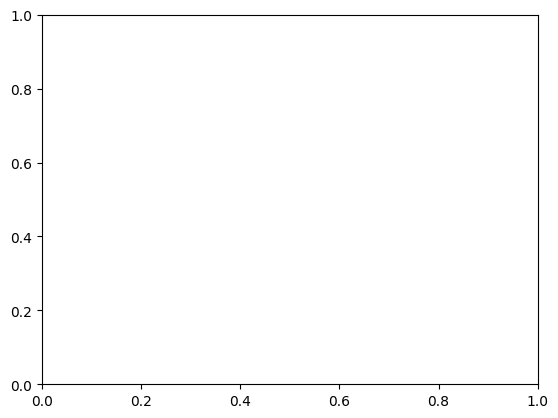

In [78]:
fig, ax = plt.subplots()
for i in range(len(df_xmatch_unique)):
        plot_group_unique(df_xmatch_unique,df_xmatch_unique["source_id"][i], ax,"table")

In [79]:
df_xmatch_repeated = df_xmatch_repeated.loc[df_xmatch_repeated["constain"]==1]
df_xmatch_unique = df_xmatch_unique.loc[df_xmatch_unique["constain"]==1]
df_xmatch_repeated['num_espectros'] = df_xmatch_repeated.groupby('index')['index'].transform('count')

In [80]:
df_xmatch = pd.concat([df_xmatch_repeated,df_xmatch_unique])

In [81]:
df_xmatch.loc[df_xmatch["num_espectros"].isna(),"num_espectros"] = 1

In [83]:
df_xmatch

,SNRG,RA_OBS,DEC_OBS,DESIG,HELIO,VACUUM,HELIO_RV,fits_name,FIB_MASK,col1,...,phot_g_mean_mag-phot_rp_mean_mag,phot_bp_mean_mag-phot_rp_mean_mag,duplicated,B3,B3_cut_probability,GroupID,GroupSize,Separation,constain,num_espectros
0,46.58,102.504620,20.152506,LAMOST J065001.10+200909.0,True,True,-3.75374,spec-56287-GAC101N22V5_sp07-175.fits,64.0,78135,...,0.496660,0.793485,NaN,NaN,0.625000,1.0,3.0,0.074466,1.0,3.0
1,133.41,55.985158,45.161518,LAMOST J034356.43+450941.4,True,True,22.07819,spec-57406-HD033226N460324V01_sp06-209.fits,0.0,56292,...,0.203282,0.302008,NaN,NaN,0.660833,2.0,3.0,0.020120,1.0,3.0
2,205.85,117.416880,1.597246,LAMOST J074940.05+013550.0,True,True,2.05749,spec-56316-GAC118N03V2_sp02-067.fits,0.0,72444,...,-0.087619,-0.153430,NaN,NaN,0.660000,3.0,4.0,3.279236,1.0,4.0
3,171.21,182.640751,18.589351,LAMOST J121033.78+183521.6,True,True,-23.76457,spec-58868-HD121513N165426V02_sp16-059.fits,192.0,77575,...,-0.039443,-0.065139,NaN,NaN,0.615833,4.0,3.0,0.065964,1.0,3.0
4,156.08,23.418617,46.896370,LAMOST J013340.46+465346.9,True,True,-8.11896,spec-57675-HD014236N482459V01_sp02-036.fits,16.0,66485,...,-0.090764,-0.149240,NaN,NaN,0.666667,5.0,2.0,1.336745,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,139.06,94.178112,22.961417,LAMOST J061642.74+225741.1,True,True,15.77756,spec-58875-HD062534N222728V01_sp14-200.fits,64.0,79007,...,0.687284,1.191796,NaN,NaN,0.611667,NaN,NaN,0.037799,1.0,1.0
76,341.42,98.174933,17.398165,LAMOST J063241.98+172353.3,True,True,-25.59045,spec-58423-TD062610N184524B01_sp07-176.fits,64.0,77217,...,0.363739,0.550712,NaN,NaN,0.675000,NaN,NaN,0.016467,1.0,1.0
77,292.78,31.498759,52.915553,LAMOST J020559.70+525455.9,True,True,-4.14120,spec-57328-HD020325N544136V01_sp01-103.fits,64.0,89820,...,0.071296,0.097650,NaN,NaN,0.605833,NaN,NaN,0.011765,1.0,1.0
78,164.63,99.636545,6.139945,LAMOST J063832.77+060823.8,True,True,21.66151,spec-55976-GAC_099N04_V5_sp15-026.fits,64.0,40327,...,0.236401,0.355920,NaN,NaN,0.630833,NaN,NaN,0.163639,1.0,1.0


In [45]:
df_xmatch.to_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_not_searched.csv",index=False)

In [85]:
df_xmatch_repeated

,SNRG,RA_OBS,DEC_OBS,DESIG,HELIO,VACUUM,HELIO_RV,fits_name,FIB_MASK,col1,...,phot_g_mean_mag-phot_rp_mean_mag,phot_bp_mean_mag-phot_rp_mean_mag,duplicated,B3,B3_cut_probability,GroupID,GroupSize,Separation,constain,num_espectros
0,46.58,102.504620,20.152506,LAMOST J065001.10+200909.0,True,True,-3.75374,spec-56287-GAC101N22V5_sp07-175.fits,64.0,78135,...,0.496660,0.793485,NaN,NaN,0.625000,1.0,3.0,0.074466,1.0,3
1,133.41,55.985158,45.161518,LAMOST J034356.43+450941.4,True,True,22.07819,spec-57406-HD033226N460324V01_sp06-209.fits,0.0,56292,...,0.203282,0.302008,NaN,NaN,0.660833,2.0,3.0,0.020120,1.0,3
2,205.85,117.416880,1.597246,LAMOST J074940.05+013550.0,True,True,2.05749,spec-56316-GAC118N03V2_sp02-067.fits,0.0,72444,...,-0.087619,-0.153430,NaN,NaN,0.660000,3.0,4.0,3.279236,1.0,4
3,171.21,182.640751,18.589351,LAMOST J121033.78+183521.6,True,True,-23.76457,spec-58868-HD121513N165426V02_sp16-059.fits,192.0,77575,...,-0.039443,-0.065139,NaN,NaN,0.615833,4.0,3.0,0.065964,1.0,3
4,156.08,23.418617,46.896370,LAMOST J013340.46+465346.9,True,True,-8.11896,spec-57675-HD014236N482459V01_sp02-036.fits,16.0,66485,...,-0.090764,-0.149240,NaN,NaN,0.666667,5.0,2.0,1.336745,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,172.82,61.950540,45.353611,LAMOST J040748.12+452112.9,True,True,-7.48198,spec-56611-GAC061N46V2_sp01-150.fits,128.0,57972,...,0.406132,0.617950,NaN,NaN,0.678333,32.0,2.0,0.061066,1.0,2
74,173.41,61.950540,45.353611,LAMOST J040748.12+452112.9,True,True,18.76204,spec-55939-GAC_061N46_V2_sp01-150.fits,64.0,57972,...,0.406132,0.617950,NaN,NaN,0.678333,32.0,2.0,0.061066,1.0,2
75,117.96,100.523240,16.456760,LAMOST J064205.57+162724.3,True,True,24.12175,spec-55981-GAC_100N17_V4_sp05-138.fits,64.0,76904,...,0.209100,0.313097,NaN,NaN,0.620833,21.0,3.0,0.115902,1.0,3
76,143.07,96.439242,19.704677,LAMOST J062545.41+194216.8,True,True,-25.17271,spec-58423-TD062610N184524B01_sp15-176.fits,64.0,97790,...,0.281139,0.428100,NaN,NaN,0.622500,24.0,2.0,0.021685,1.0,2


In [82]:
print(f"Spectral information match for not unique source ID gaia within 5 arcsec {Sources_no_uniques_5arcsec}")
print(f"Is there more than one gaia source in each group? {Fuente_gaia_en_Groupid}")
print(f"Gaia sources unique with multispectrum {source_con_mas_de_un_espectro}")

Spectral information match for not unique source ID gaia within 5 arcsec 78
Is there more than one gaia source in each group? False
Gaia sources unique with multispectrum 32


## Calcular EW

In [23]:
def plot_spec_norm(filename, index, snr):
    flux, ivar, wave, andmask, ormask, norm = open_fits(filename)
    df_continuo, _ = normalize_spectra(wave, flux, ivar, 1, [4000,5000])
    df_continuo["flux_norm"] = df_continuo["flux_norm"] + index / 2
    
    # Graficar la curva normalizada
    plt.plot(df_continuo["lambda"], df_continuo["flux_norm"], c="black")
    df_plot = df_continuo.loc[(df_continuo["lambda"] > 4600) & (df_continuo["lambda"] < 4700)]
    
    # Agregar texto SNR en el gráfico. Ajusta las coordenadas y el texto según necesites.
    plt.text(4550, df_plot["flux_norm"].median() + 0.08, f'SNR: {snr:.0f}', size=8)
    return

In [24]:
df_information = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_not_searched.csv")

In [25]:
lines = {

    "He I 4144": {
        "spectral_line": (4140, 4150),
        "continuum_blue": (4035, 4060),
        "continuum_red": (4150, 4170)
    },
    "He I+He II 4026": {
        "spectral_line": (4017, 4034),
        "continuum_blue": (3990, 4002),
        "continuum_red": (4035, 4060)
    },
    "He I 4387": {
        "spectral_line": (4382, 4392),
        "continuum_blue": (4365, 4380),
        "continuum_red": (4398, 4415)
    },
    "Fe II 4233": {
        "spectral_line": (4229, 4237),
        "continuum_blue": (4205, 4225),
        "continuum_red": (4238, 4260)
    },
    "He I 4471": {
        "spectral_line": (4462, 4477),
        "continuum_blue": (4440, 4460),
        "continuum_red": (4495, 4535)
    },
    "He II 4200": {
        "spectral_line": (4190, 4207),
        "continuum_blue": (4150, 4190),
        "continuum_red": (4245, 4260)
    },
    "Mg II 4481": {
        "spectral_line": (4477, 4488),
        "continuum_blue": (4440, 4460),
        "continuum_red": (4490, 4505)
    },
    "He II 4541": {
        "spectral_line": (4537, 4547),
        "continuum_blue": (4510, 4535),
        "continuum_red": (4590, 4620)
    },
    "He II 4686": {
        "spectral_line": (4679, 4692),
        "continuum_blue": (4660, 4670),
        "continuum_red": (4730, 4745)
    }
}

for key, values in lines.items():
    lines[key]['central_lambda'] = float(key.split()[-1])

In [26]:
for key in list(lines.keys()):
    detection = f'{key}_type'
    EW_name = f'{key}_EW'
    fitting_name = f'{key}_fit'
    df_information[[EW_name,detection,fitting_name]] = df_information.parallel_apply(
            lambda row: main_function(
            row["fits_name"],
            row["HELIO_RV"],
            row["B3_cut_probability"],
            lines[key]["continuum_blue"],
            lines[key]["continuum_red"],
            lines[key]["spectral_line"],
            lines[key]["central_lambda"],
            5
        ),
        axis=1,
        result_type="expand")

In [27]:
df_information = df_information.loc[df_information["He I 4144_EW"]!="error"]
# 2 estrellas con error al abrir el fits

In [29]:
key = "He I 4471"
df_information[["THeI4471","TMgII4481"]]= df_information.parallel_apply(
            lambda row: main_HeIMgII(
            row["fits_name"],
            row["HELIO_RV"],
            row["B3_cut_probability"],
            lines[key]["continuum_blue"],
            lines[key]["continuum_red"],
            lines[key]["spectral_line"],
            lines[key]["central_lambda"],
            5
        ),
        axis=1,result_type="expand")
teoric_He_over_Mg = df_information["THeI4471"]/ df_information["TMgII4481"]

In [30]:
df_information["BHeMg"] = df_information["He I 4471_EW"] / df_information["Mg II 4481_EW"] 
df_information["THeMg"] =  teoric_He_over_Mg

df_information = df_information.sort_values(by="SNRG",ascending=False).drop_duplicates(subset="source_id")
lamost =  df_information.loc[df_information["SNRG"]>50].reset_index(drop=True)

lamost["sp"] = np.nan


In [31]:
lamost.loc[((lamost["He II 4686_type"]=="abs")&(lamost["He II 4541_type"]=="abs")),"sp"] = "O-B0"
lamost.loc[(lamost["He I 4471_type"]=="U")&
                    (lamost["Mg II 4481_type"]!="U") &
                    (lamost["sp"].isna()),"sp"] = "Later"
lamost.loc[(lamost["He I 4471_type"]!="U")&
                    (lamost["Mg II 4481_type"]=="U") &
                    (lamost["sp"].isna()),"sp"] = "B0-B3"
lamost.loc[(lamost["He I 4471_type"]!="U")&
            (lamost["Mg II 4481_type"]=="U")&
            (lamost["He I 4144_type"]=="U")&
                (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] >= 3)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B0-B3"
lamost.loc[(lamost["THeMg"] > 1)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] <= 1)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B8-A1"
lamost.loc[(lamost["THeMg"] > 1)&
                    (lamost["He I+He II 4026_type"]=="abs") &
                   ( (lamost["Fe II 4233_type"]=="U")|(lamost["Fe II 4233_EW"]<=0.15))&
                    (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] <= 1)&
                    (lamost["He I+He II 4026_type"]=="abs") &
                     ( (lamost["Fe II 4233_type"]=="U")|(lamost["Fe II 4233_EW"]<=0.15))&
                    (lamost["sp"].isna()),"sp"] = "B8-A1"

lamost.loc[(lamost["He I 4144_type"]!="abs") &
                    (lamost["He I+He II 4026_type"]!="abs") &
                    (lamost["sp"].isna()),"sp"] = "Later"

lamost.loc[(lamost["He I 4144_type"]!="abs") &
                    (lamost["He I+He II 4026_type"]=="abs") &
                    (lamost["Fe II 4233_EW"]>0.15)&
                    (lamost["sp"].isna()),"sp"] = "Later"

/tmp/ipykernel_8479/2658578078.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'O-B0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  lamost.loc[((lamost["He II 4686_type"]=="abs")&(lamost["He II 4541_type"]=="abs")),"sp"] = "O-B0"


In [33]:
lamost.to_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_not_searched_sp.csv")

In [67]:
#lamost = lamost.loc[lamost["B3_cut_p"].isna()]

In [22]:
lamost= pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv")

In [68]:
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Crear una nueva columna con los bins
lamost['prob_bin'] = pd.cut(lamost['B3_cut_probability'], bins=bins, labels=labels, right=True)

# Agrupar por 'prob_bin' y 'sp', y contar las ocurrencias
counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)

/tmp/ipykernel_636434/2615482075.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)


In [69]:
mpl.rcParams['text.usetex'] = True  # Habilita el uso de LaTeX

NameError: name 'mpl' is not defined

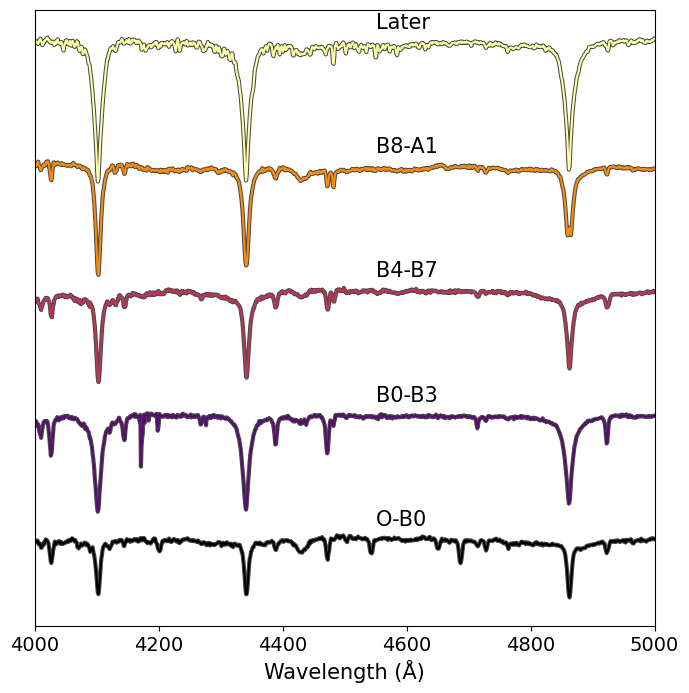

In [42]:
# Crear la figura antes de llamar a la función de ploteo
plt.figure(figsize=(8, 8))  # Ajusta el tamaño de la figura según lo que necesites

def plot_spec_norm(filename, index, snr, sp):
    flux, ivar, wave, andmask, ormask, norm = open_fits(filename)
    colors = plt.cm.inferno_r(np.linspace(0, 1, counts.shape[1]))[::-1]
    df_continuo, _ = normalize_spectra(wave, flux, ivar, 1, [4000, 5000])
    df_continuo["flux_norm"] = df_continuo["flux_norm"] + index / 1.5
    
    # Graficar la curva normalizada en la figura actual
    plt.plot(df_continuo["lambda"], df_continuo["flux_norm"], c='black', linewidth=3, alpha=0.7, zorder=1)

    # Dibujar la línea de color encima
    plt.plot(df_continuo["lambda"], df_continuo["flux_norm"], c=colors[index], linewidth=1.5, zorder=2)
    df_plot = df_continuo.loc[(df_continuo["lambda"] > 4600) & (df_continuo["lambda"] < 4700)]
    
    # Agregar texto con el tipo espectral (sp) en el gráfico
    plt.text(4550, df_plot["flux_norm"].median() + 0.08, f'{sp}', size=15)
    
    # Añadir líneas verticales en las posiciones especificadas
#    plt.axvline(x=4471, color='r', linestyle='dotted', alpha=0.1)
#    plt.axvline(x=4542, color='r', linestyle='dotted', alpha=0.1)
#    plt.axvline(x=4686, color='r', linestyle='dotted', alpha=0.1)

# Ordenar el DataFrame por SNRG en orden descendente y filtrar
lamost_sorted = lamost.loc[(lamost["SNRG"] > 200) & (lamost["SNRG"] < 280)]

# Crear un nuevo DataFrame que contenga solo la fila con el mayor SNRG para cada valor único de 'sp'
df_var = pd.DataFrame()
for sp_value in ['O-B0', 'B0-B3', 'B4-B7', 'B8-A1', 'Later']:  # Orden directo
    highest_snr_row = lamost_sorted.loc[lamost_sorted["sp"] == sp_value].iloc[0]
    df_var = pd.concat([df_var, pd.DataFrame([highest_snr_row])], ignore_index=True)

# Aplicar la función de plot a cada fila seleccionada
df_var.apply(lambda row: plot_spec_norm(row["fits_name"],
                                        row.name,
                                        row["SNRG"],
                                        row["sp"]),
             axis=1)

plt.ylabel("")
plt.yticks([])
plt.xlabel('Wavelength (\u212B)', size=15)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f"{path_plots}/example_classification_lamost.pdf", format='pdf', bbox_inches='tight')
# Mostrar todos los gráficos en la misma figura
plt.xlim(4000,5000)
plt.show()




In [36]:
path_plots

'/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/plots/'

In [72]:
def create_spectra_pdf(lamost, sp_value,sort_value, pdf_name, spectra_per_page):
    # Filtrar los datos según el valor de `sp`
    df_variable = lamost.loc[(lamost["sp"] == sp_value)].reset_index(drop=True)
    df_variable = df_variable.sort_values(by=sort_value,ascending=False).reset_index(drop=True)
    # Número total de espectros y número de páginas necesarias
    num_spectra = len(df_variable)
    num_pages = (num_spectra + spectra_per_page - 1) // spectra_per_page  # Redondeo hacia arriba

    # Crear el PDF
    with PdfPages(f"{pdf_name}.pdf") as pdf:
        for page in range(num_pages):
            plt.figure(figsize=(8.27, 11.69))  # Tamaño A4 en pulgadas
            start_index = page * spectra_per_page
            end_index = min(start_index + spectra_per_page, num_spectra)
            for index in range(start_index, end_index):
                row = df_variable.iloc[index]
                plot_spec_norm(row["fits_name"], index, row["SNRG"],row["ra"],row["dec"])
            plt.tight_layout()
            pdf.savefig()  # Guardar la página en el PDF
            plt.close()
    return

In [73]:
create_spectra_pdf(lamost, "B0-B3","He I 4471_EW", "B0_B3",16)

In [74]:
create_spectra_pdf(lamost, "O-B0","He II 4686_EW", "O_B0", 17)

In [75]:
create_spectra_pdf(lamost, "B4-B7","Mg II 4481_EW", "B4_B5", 20)

In [76]:
create_spectra_pdf(lamost, "B8-A1","Mg II 4481_EW", "B6_B9", 20)

In [77]:
create_spectra_pdf(lamost, "Later","SNRG", "Later", 20)

In [399]:
lamost.to_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv",index=False)

## Revisar cambio de threshold de B2 a B3

In [1]:
import pandas as pd

In [4]:
clasificaciones_lamost_B2 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv")
clasificaciones_lamost_B3 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_not_searched.csv")
data_B2 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
data_B3 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv")

/tmp/ipykernel_8130/3049147886.py:3: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  data_B2 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
/tmp/ipykernel_8130/3049147886.py:4: DtypeWarning: Columns (50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data_B3 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv")


In [7]:
data_B3 = data_B3.merge(data_B2[["index","B2_cut_probability"]],how="left",on="index")

,Unnamed: 0,index,source_id,ra,dec,ra_error,dec_error,parallax,parallax_error,parallax_over_error,...,ks_m-phot_g_mean_mag,ks_m-phot_bp_mean_mag,ks_m-phot_rp_mean_mag,phot_g_mean_mag-phot_bp_mean_mag,phot_g_mean_mag-phot_rp_mean_mag,phot_bp_mean_mag-phot_rp_mean_mag,duplicated,B3,B3_cut_probability,B2_cut_probability
0,0,4377,5867262056094720256,210.788953,-60.399609,0.005978,0.009415,0.351307,0.012514,28.072306,...,-1.946995,-2.459917,-1.244953,-0.512922,0.702042,1.214964,NaN,1.0,0.951667,0.928333
1,1,1036997,465798136783420032,40.879047,62.059394,0.016799,0.018728,0.297585,0.026911,11.058279,...,-1.330405,-1.560003,-0.914638,-0.229598,0.415767,0.645365,NaN,1.0,0.857500,0.847500
2,2,572316,5864666727635499904,206.640463,-62.889316,0.018872,0.022404,0.609050,0.033216,18.336296,...,-0.174629,-0.212529,-0.059639,-0.037900,0.114990,0.152890,NaN,1.0,0.777500,0.708333
3,3,400503,5311906841793959936,139.155186,-51.939581,0.010610,0.011651,0.364554,0.011761,30.996029,...,-1.528118,-1.914056,-0.948690,-0.385938,0.579428,0.965366,NaN,1.0,0.970833,0.971667
4,4,225971,5350357313186767104,161.140513,-59.737608,0.021567,0.021763,0.430756,0.024832,17.346905,...,-0.321917,-0.352225,-0.180605,-0.030308,0.141312,0.171620,NaN,1.0,0.972500,0.960000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,99383,1090775,5930430098664887296,248.531434,-54.448183,0.013537,0.009705,0.662841,0.017796,37.247540,...,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995,NaN,NaN,0.235000,0.215000
99384,99384,1090785,203937691597823488,69.770362,41.249985,0.016364,0.009660,1.189286,0.019677,60.441757,...,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237,NaN,NaN,0.615833,0.450000
99385,99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,NaN,NaN,0.777500,0.783333
99386,99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,NaN,NaN,0.920833,0.907500


## Revisar clasificacion espectral con respecto a las probabilidades

Estamos viendo si el problema son las etiquetas o las features no son suficientes para clasificar.

Histograma de las probabilidades de los confirmados y en otro color la probabilidad de los contaminantes

Espacio original del random forest y miro si en ese espacio de contaminantes y no contaminantes

DB scan algo forzando 3 clusters, estan los objetos de un tipo o de otro tipo principalmente en el mismo cluster
como se comparan todos los parametros en mi muestra total

In [43]:
import pandas as pd

In [44]:
lamost = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv")

In [70]:
lamost.loc[(lamost["sp"]=="B0-B3")|(lamost["sp"]=="O-B0"),"masiva"] = 1
lamost.loc[(lamost["masiva"].isna()),"masiva"] = 0

In [74]:
lamost.groupby("sp").count()

,SNRG,RA_OBS,DEC_OBS,DESIG,HELIO,VACUUM,HELIO_RV,fits_name,FIB_MASK,col1,...,He II 4541_fit,He II 4686_EW,He II 4686_type,He II 4686_fit,THeI4471,TMgII4481,BHeMg,THeMg,prob_bin,masiva
sp,,,,,,,,,,,,,,,,,,,,,
B0-B3,52,52,52,52,52,52,52,52,52,52,...,52,6,52,52,52,52,35,52,52,52
B4-B7,24,24,24,24,24,24,24,24,24,24,...,24,9,24,24,24,24,24,24,24,24
B8-A1,6,6,6,6,6,6,6,6,6,6,...,6,5,6,6,6,6,6,6,6,6
Later,6,6,6,6,6,6,6,6,6,6,...,6,3,6,6,3,3,3,3,6,6


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definir los bins y las etiquetas
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Crear una nueva columna con los bins
lamost['prob_bin'] = pd.cut(lamost['B3_cut_probability'], bins=bins, labels=labels, right=True)

# Agrupar por 'prob_bin' y 'sp', y contar las ocurrencias
counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)

counts = counts[["Later", "B8-A1", "B4-B7", "B0-B3", "O-B0"]]

# Calcular el total y los 'unos' por bin de probabilidad
detections = lamost.groupby('prob_bin')['masiva'].agg(total='count', unos='sum')

# Calcular el porcentaje de detección
detections['porcentaje'] = (detections['unos'] / detections['total']) * 100

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(8, 8))

# Obtener los colores para las categorías de 'sp'
colors = plt.cm.inferno_r(np.linspace(0, 1, counts.shape[1]))

# Dibujar las barras apiladas
counts.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')

# Ajustar los límites del eje y
ax.set_ylim(0, counts.values.sum(axis=1).max() * 1.1)

# Agregar el porcentaje de detección al lado derecho de cada barra
for idx, (bin_label, row) in enumerate(counts.iterrows()):
    total = row.sum()
    porcentaje = detections.loc[bin_label, 'porcentaje']
    x = idx
    y = total
    ax.text(x, y + (ax.get_ylim()[1] * 0.01), f'{porcentaje:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Configurar etiquetas y título
ax.set_xlabel('BRF Probability', fontsize=20)
ax.set_ylabel('', fontsize=16)

# Mover la leyenda fuera del gráfico
ax.legend(title='Spectral Type', fontsize=20, title_fontsize=20)

# Ajustar el tamaño de las etiquetas del eje x e y
ax.tick_params(axis='x', labelsize=20)  # Aumentar el tamaño de los ticks del eje x
ax.tick_params(axis='y', labelsize=20)  # Aumentar el tamaño de los ticks del eje y

# Ajustar las etiquetas del eje x
plt.xticks(rotation=0)

# Ajustar el diseño
plt.tight_layout()

plt.savefig(f"{path_plots}/Detection_rate.pdf", format='pdf', bbox_inches='tight')
# Mostrar el gráfico
plt.show()



/tmp/ipykernel_636434/2415219546.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)


KeyError: "['O-B0'] not in index"

In [106]:
# Supongamos que `lamost.groupby("sp").count() / len(lamost)` es `grouped_df`
grouped_df = lamost.groupby("sp").count() / len(lamost)

# Define el orden personalizado
custom_order = ["Later", "B8-A1", "B4-B7", "B0-B3", "O-B0"]

# Convierte el índice a un tipo categórico con el orden específico
grouped_df.index = pd.Categorical(grouped_df.index, categories=custom_order, ordered=True)

# Ordena el DataFrame por el índice categórico
sorted_df = grouped_df.sort_index()

In [107]:
sizes = sorted_df.round(4)["index"].values
labels = sorted_df.round(4)["index"].index

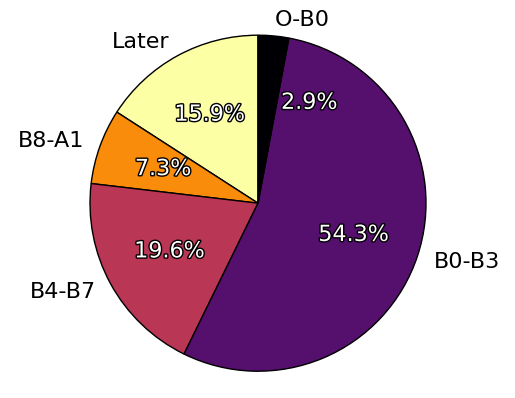

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects

# Paleta de colores 'colorblind' de Seaborn
colors = plt.cm.inferno_r(np.linspace(0, 1, counts.shape[1]))

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects


# Crear el gráfico de pastel
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 16}
)

# Aplicar color blanco y contorno negro a los porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    # Ajustar la posición del '2.9%' hacia la derecha
    if autotext.get_text() == '2.9%':
        x, y = autotext.get_position()
        autotext.set_position((x + 0.25, y))  # Mover 0.05 unidades a la derecha

# Asegurar que el gráfico es un círculo perfecto
ax.axis('equal')

plt.savefig(f"{path_plots}/pie_chart_lamost.pdf", format='pdf', bbox_inches='tight')
# Mostrar el gráfico
plt.show()


14.952

In [53]:
lamost.loc[(lamost["sp"]=="B0-B3")|(lamost["sp"]=="O-B0"),"SpT"] = "Buenos"

In [ ]:
lamost

In [54]:
sp_for_plot = ['B0-B3', 'B8-A1', 'Later', 'O-B0', 'B4-B7']

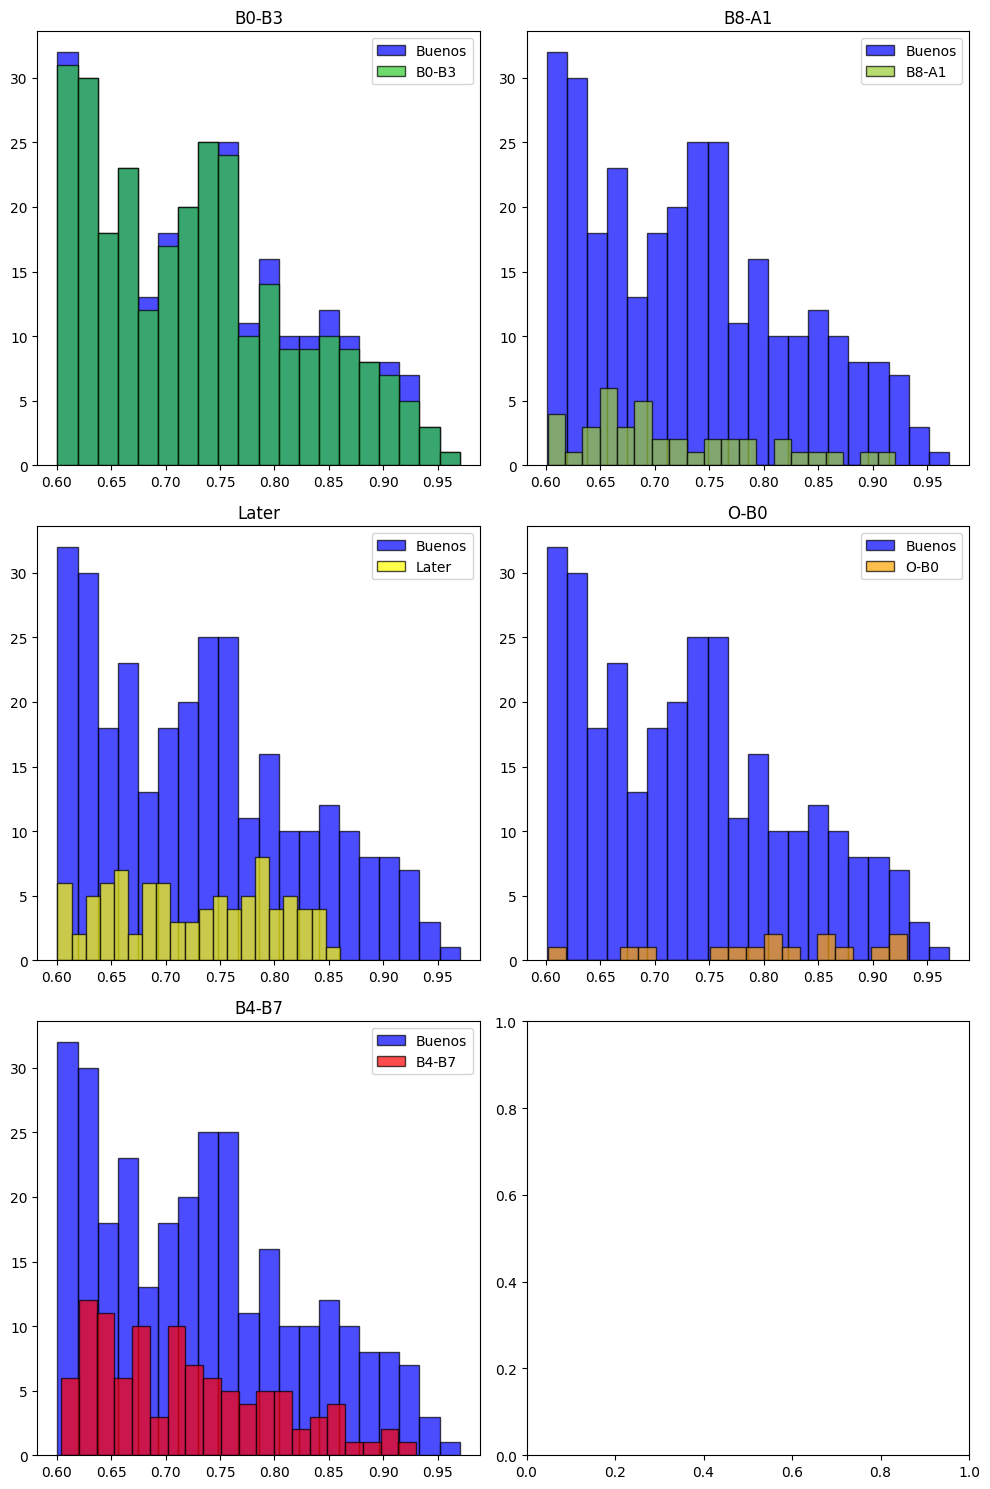

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'df_information' y 'sp_for_plot' ya están definidos
colors = [    # Azul claro
    'limegreen',       # Verde brillante, neutro
    'yellowgreen',
    "yellow",
    'orange',        # Naranja
    'red'            # Rojo caliente
]  # Azul para 'Buenos', naranja para la categoría actual

# Obtener los datos específicos para "Buenos"
df_buenos = lamost.loc[lamost["SpT"] == "Buenos"]["B2_cut_probability"]

# Inicializar la figura de subplots con 2 filas y 3 columnas
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))  # Ajusta el tamaño de la figura según sea necesario

# Aplanar el array de ejes para facilitar el acceso por índice
axes = axes.flatten()

# Iterar a través de cada subconjunto de datos para los diferentes 'sp'
for i, sp in enumerate(sp_for_plot):
    if i < len(axes):  # Asegurarse de que no se exceda el número de subplots disponibles
        data = lamost.loc[lamost["sp"] == sp]["B2_cut_probability"]
        
        # Dibujar dos histogramas independientes en el mismo subplot
        axes[i].hist(df_buenos, bins=20, color='blue', edgecolor='black', label="Buenos", alpha=0.7)
        axes[i].hist(data, bins=20, color=colors[i], edgecolor='black', label=sp, alpha=0.7)
        
        axes[i].legend()
        axes[i].set_title(sp)

# Ajustar los subplots y mostrar la figura
plt.tight_layout()
plt.show()




In [62]:
lamost.loc[lamost["SpT"]=="Buenos"].to_csv("Estrellas_Masivas_clasificadas_LAMOST.csv",index=False)

<Axes: xlabel='4471_sigma', ylabel='Count'>

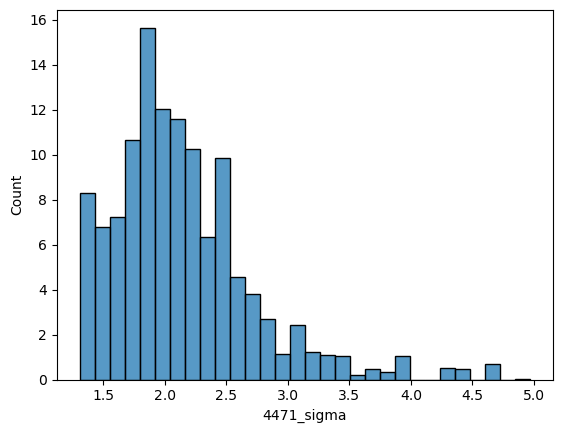

In [133]:
sns.histplot(data=df_information_detected.loc[df_information_detected["4471_sigma"]<5],
             x="4471_sigma",bins=30,
             weights="4471_significancia_norm")
#plt.axvline(x=2.4, color='black', linestyle='--')

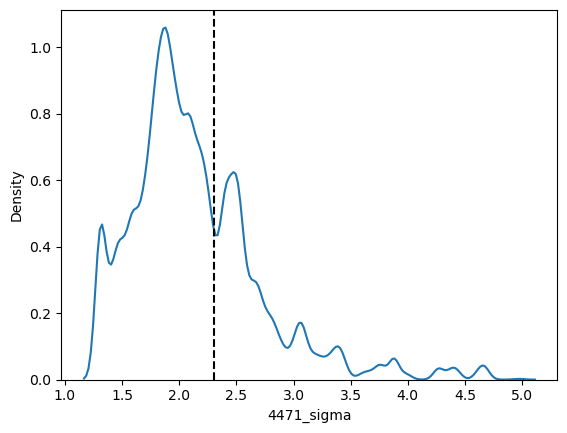

In [140]:
sns.kdeplot(data=df_information_detected.loc[df_information_detected["4471_sigma"]<5],x="4471_sigma",
            weights="4471_significancia_norm"
           ,bw_adjust=.25)
plt.axvline(x=2.3, color='black', linestyle='--')

In [151]:
(900/950)*1300

1231.578947368421

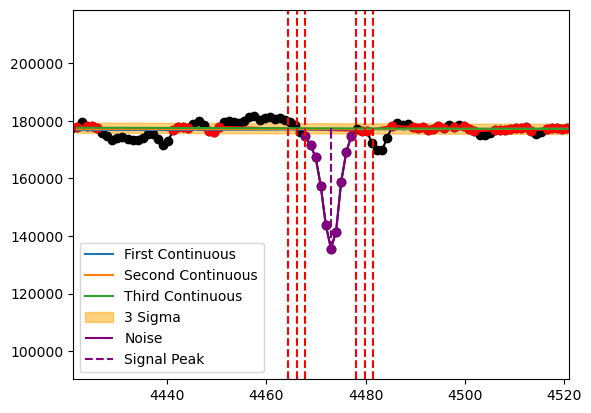

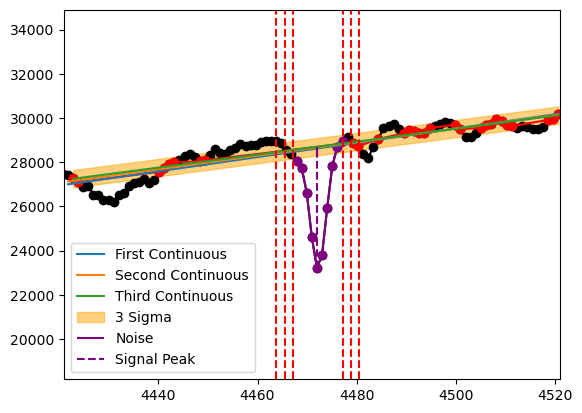

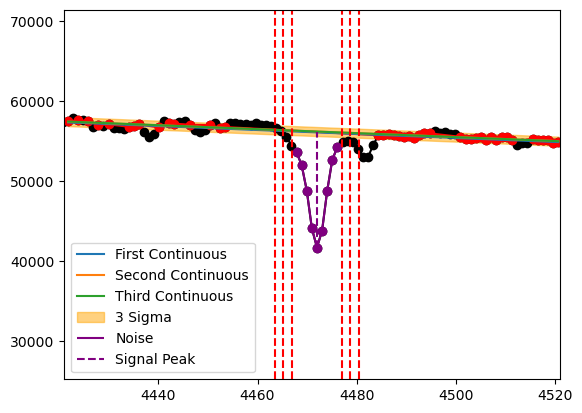

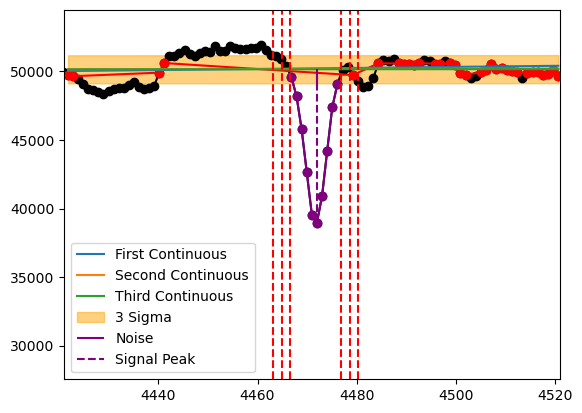

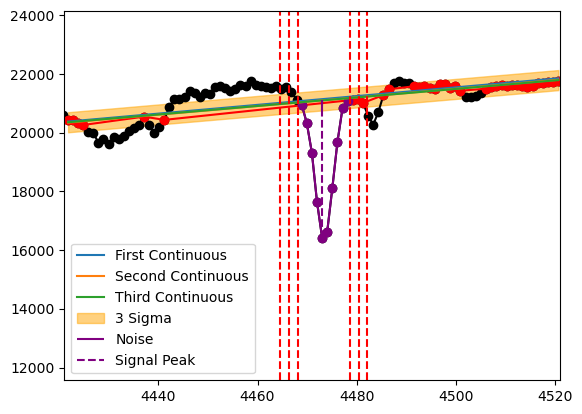

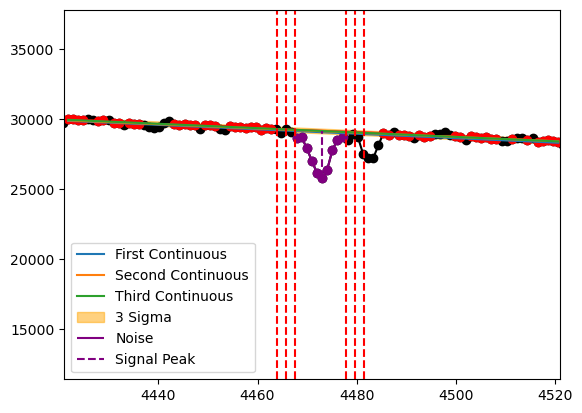

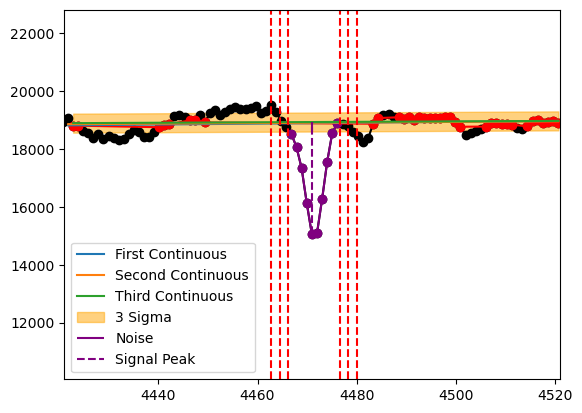

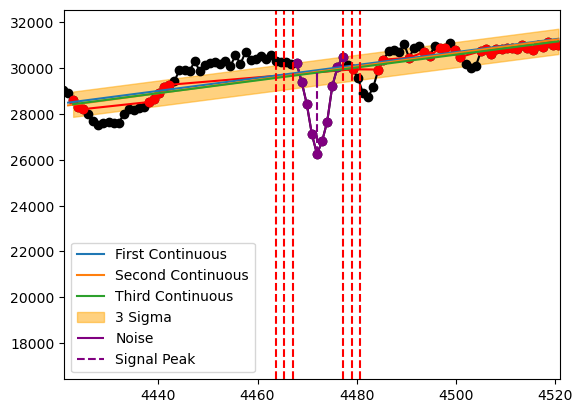

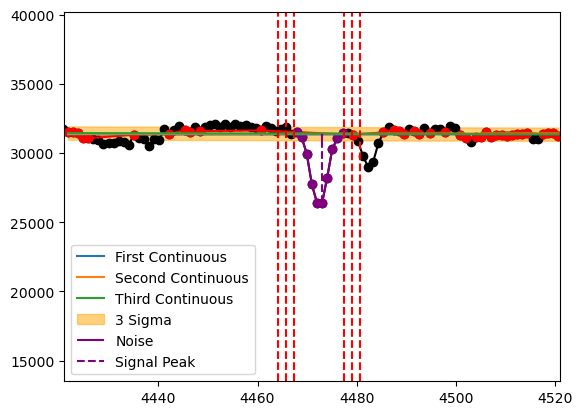

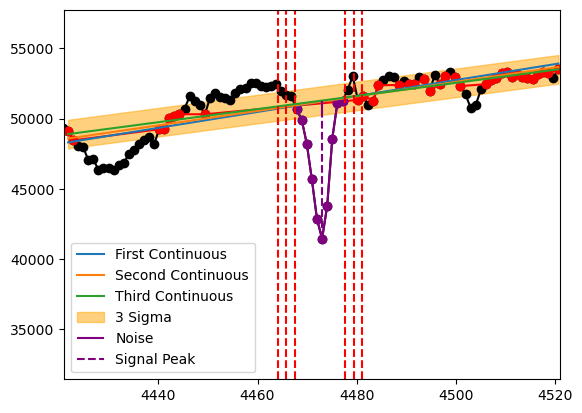

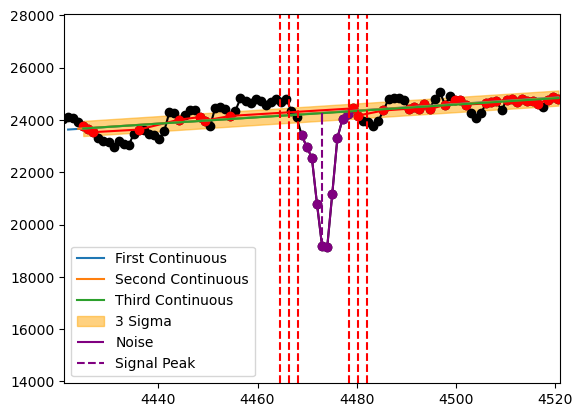

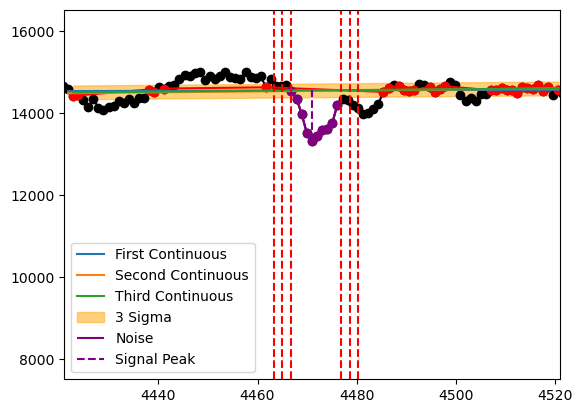

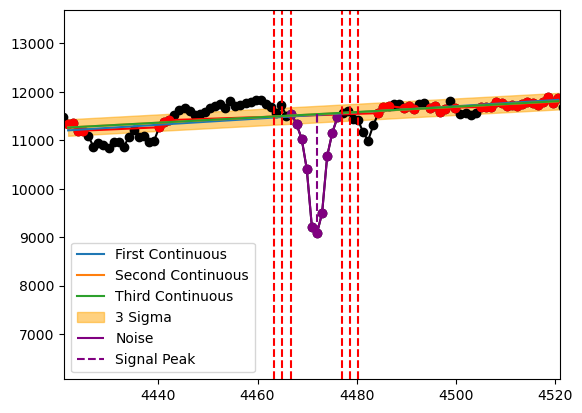

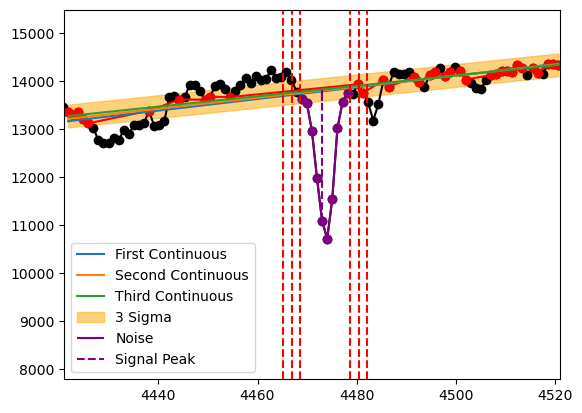

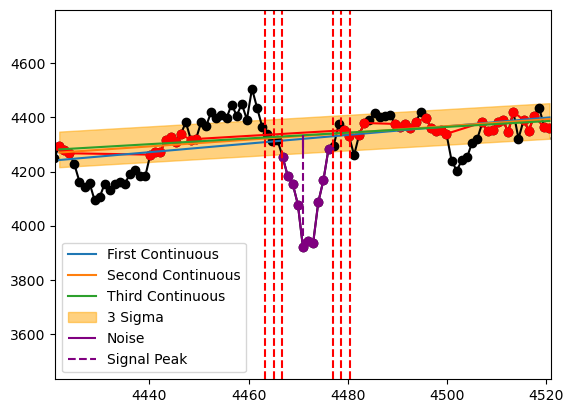

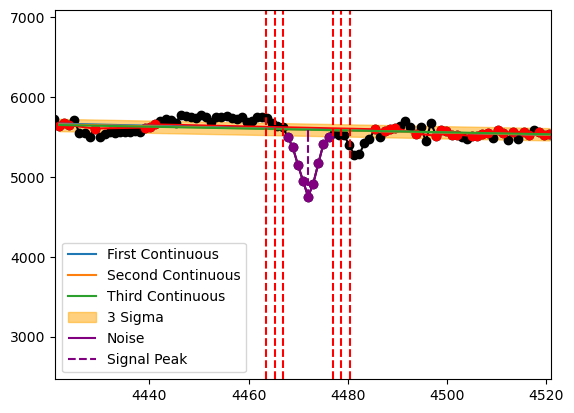

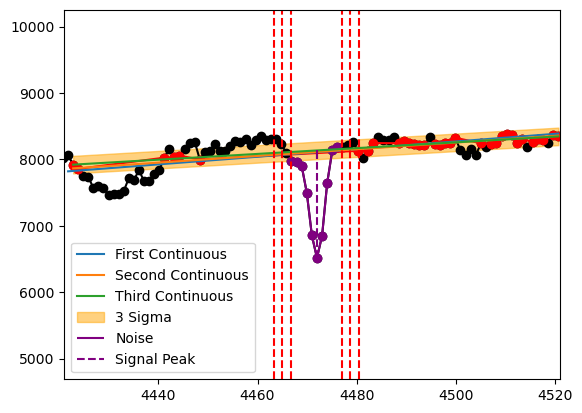

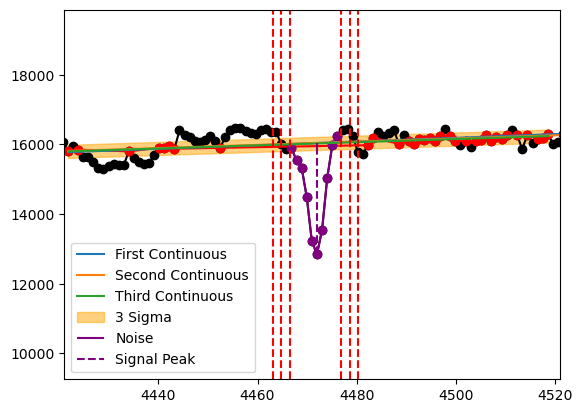

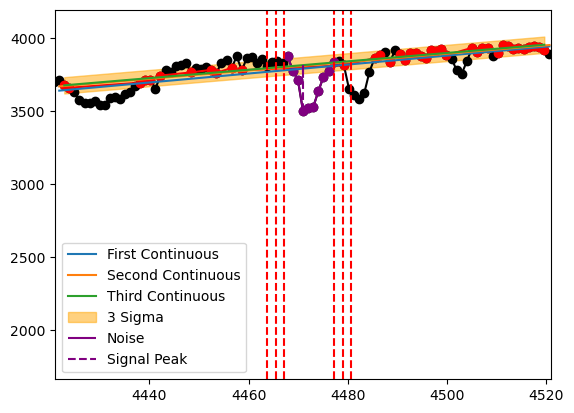

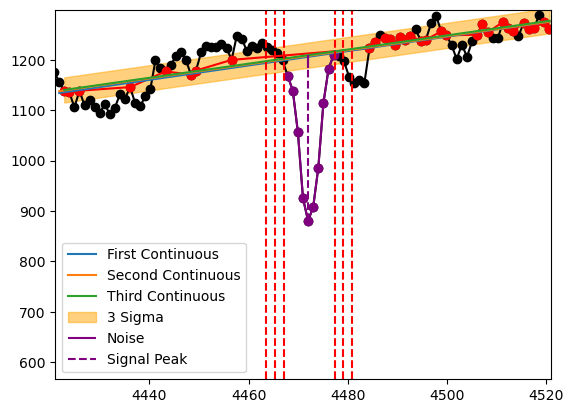

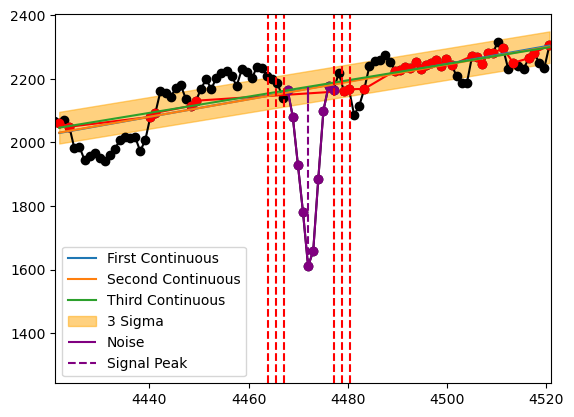

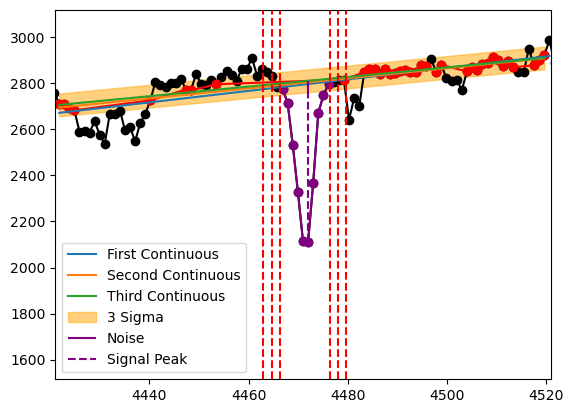

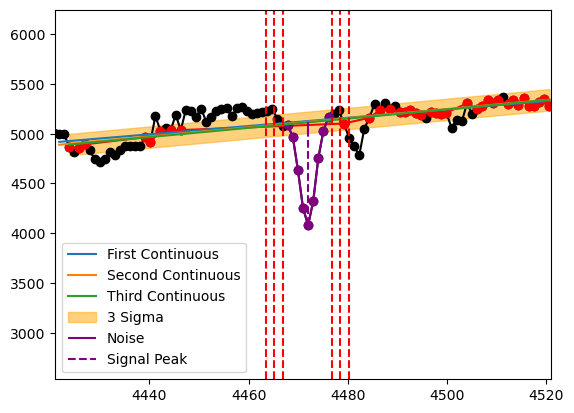

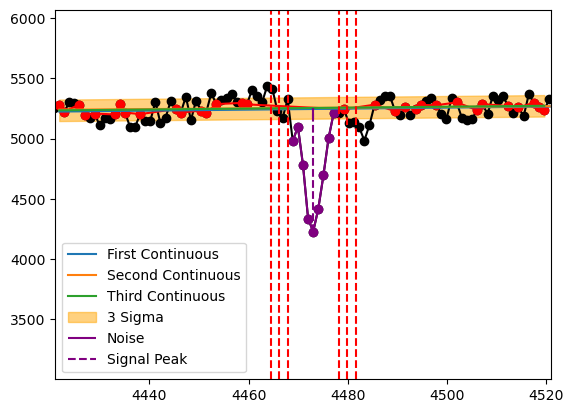

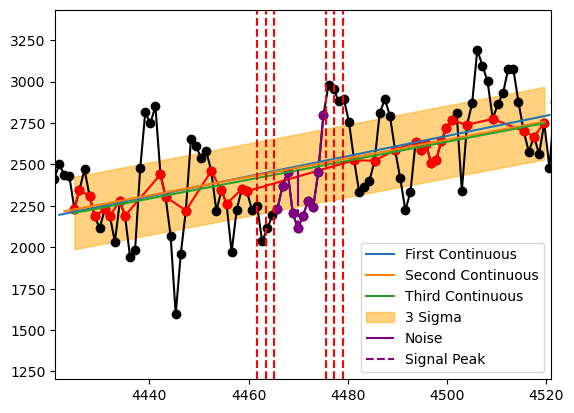

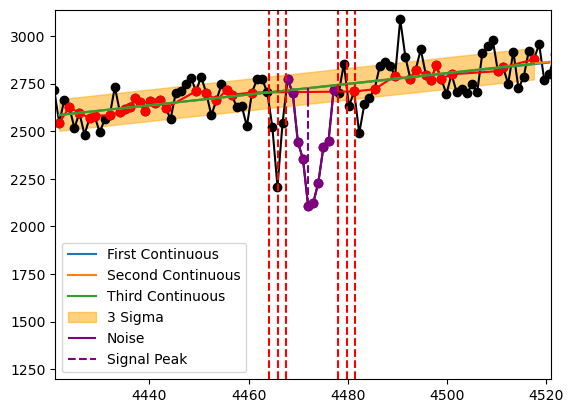

,0,1,2
775,1.026919,1.715997,23.712654
704,0.773001,1.666928,13.965522
650,1.172905,1.682775,25.616042
691,1.123701,1.708469,10.920605
555,0.984559,1.749965,13.658911
174,0.543921,1.739402,20.489716
725,0.967243,1.726662,11.821690
351,0.450265,1.697202,6.435347
919,0.658447,1.656864,10.473572
770,0.779070,1.703884,9.664155


In [153]:
df_information_detected.loc[(df_information_detected["4471_sigma"]>1.65)&
                            (df_information_detected["4471_sigma"]<1.75)].apply(lambda row: calculate_EW(row["fits_name"],
                                                       linea,
                                                          1300,
                                                       [4000, 5000]),axis=1,result_type="expand")

In [ ]:
df_information.parallel_apply(lambda row: calculate_EW(row["fits_name"],
                                                           linea,
                                                              1300,
                                                           [4000, 5000]),axis=1,result_type="expand")

In [406]:
for linea in [4481,4471,4542]:
    df_information[[f"{linea}_EW3", f"{linea}_sigma", f"{linea}_significancia"]] = df_information.parallel_apply(lambda row: calculate_EW(row["fits_name"],
                                                           linea,
                                                              1300,
                                                           [4000, 5000]),axis=1,result_type="expand")

KeyboardInterrupt: 

Process ForkPoolWorker-353:
Traceback (most recent call last):
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/multiprocessing/pool.py", line 51, in starmapstar
    return list(itertools.starmap(args[0], args[1]))
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/site-packages/pandarallel/core.py", line 95, in __call__
    result = self.work_function(
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/site-packages/pandarallel/data_types/dataframe.py", line 32, in work
    return data.apply(
  File "/home/nicolas/miniconda3/envs/ESO/lib/python3.8/site-packages

In [179]:
df_information_detected = df_information.loc[(df_information["4471_EW3"] !="undetected")&
                                                (df_information["4471_EW3"] !="error")&
                                                (df_information["SNR"]>50)]

In [181]:
O = df_information_detected.loc[(df_information_detected["4542_EW3"]!="undetected")]

In [204]:
O_seguro = O.loc[O["4542_significancia"]>3]

In [270]:
O_seguro["4542/4471"] = np.absolute(O_seguro["4542_EW3"]/ O_seguro["4471_EW3"])

/tmp/ipykernel_5689/1142411984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O_seguro["4542/4471"] = np.absolute(O_seguro["4542_EW3"]/ O_seguro["4471_EW3"])


In [271]:
O_seguro.drop_duplicates(subset="source_id").sort_values(by="4542/4471",ascending=True).reset_index(drop=True)

,source_id,ra,dec,ra_error,dec_error,parallax,parallax_error,parallax_over_error,pmra,pmdec,...,4481_EW3,4481_sigma,4481_significancia,4471_EW3,4471_sigma,4471_significancia,4542_EW3,4542_sigma,4542_significancia,4542/4471
0,454837075308505088,40.965692,56.991430,0.010400,0.013688,0.382580,0.015624,24.486078,0.144195,-1.413498,...,undetected,undetected,undetected,0.824427,2.493038,8.868662,0.161571,1.326441,4.366006,0.19598
1,3113588231452301824,102.827882,0.453602,0.011160,0.010590,0.167194,0.012814,13.047732,-0.168686,0.527859,...,0.090375,1.337484,1.158042,0.714083,1.814964,5.584315,0.407089,1.693785,4.794618,0.570087
2,460289244232159360,45.605924,57.281289,0.011733,0.013068,0.368480,0.016378,22.498405,0.806983,-1.302091,...,0.811251,5.0,1.038994,0.769287,3.195864,4.800164,0.464897,3.097498,3.831356,0.604322
3,195168712708586880,79.594818,41.934998,0.015609,0.010513,0.232764,0.019109,12.180973,-0.013146,-0.523314,...,undetected,undetected,undetected,0.511781,2.23946,8.021121,0.668495,2.094345,13.029052,1.306213
4,3119852016046426112,99.714059,0.836192,0.011972,0.011192,0.135085,0.013257,10.189968,-0.164828,0.430870,...,undetected,undetected,undetected,-0.036541,2.146668,1.819871,0.721946,1.783617,9.438223,19.757403
5,193772676539511680,81.810397,39.852331,0.024347,0.018456,0.180363,0.027512,6.555887,-0.035682,-0.565098,...,undetected,undetected,undetected,0.033855,1.464462,2.378415,0.876425,1.750233,19.147061,25.887788


0    None
1    None
2    None
3    None
4    None
5    None
dtype: object

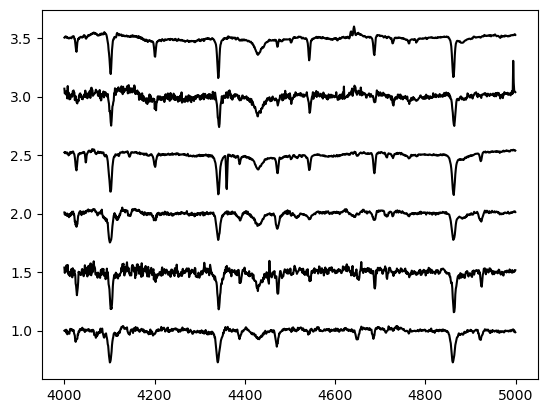

In [272]:
O_seguro.drop_duplicates(subset="source_id").sort_values(by="4542/4471",ascending=True).reset_index(drop=True).apply(lambda row: plot_spec_norm(row["fits_name"],
                                                           [4000,5000],row.name),axis=1,result_type="expand")
#plt.axvline(x=4471, color='r', linestyle='--')
#plt.axvline(x=4542, color='r', linestyle='--')

In [274]:
O_seguro.drop_duplicates(subset="source_id").sort_values(by="4542/4471",ascending=True).to_csv("O_seguras.csv",index=False)

In [858]:
low_rotators =  df_information_detected.loc[df_information_detected["4471_sigma"] < 2.2]

In [866]:
early_B_part1 = low_rotators.loc[(low_rotators["4481_significancia"] =="undetected")&(low_rotators["4542_significancia"] =="undetected")]

In [887]:
early_B_part2 = low_rotators.loc[(low_rotators["4481_EW3"] !="undetected")&(low_rotators["4481_EW3"] !="error")&(low_rotators["4542_significancia"] =="undetected")]

In [892]:
early_B_part2["4481_EW3"].unique()

array([1.1286456224280452, 0.21876223397896266, 0.1300105770427714,
       0.13704903358839393, 0.09615761209933318, 0.08700504091499467,
       1.6928787497824176, 0.2200587267147252, 1.4373115328698451,
       0.09649063928967264, 0.22805230288610837, 0.11503141750521109,
       0.16041053788313045, 0.25496602750765024, 0.21539508720842848,
       0.8522561455722201, 0.2724474074401792, 0.054272660198735764,
       0.32005541817001537, 0.16929194294210947, 0.23554941018006323,
       0.23368570324147392, 0.15744944708588618, 0.1501760040871878,
       0.24981191583676193, 0.1684908131257283, 1.6690712103760397,
       1.2204415884239985, 0.14885808526101757, 0.22446753929189223,
       0.18627787978659743, 0.2301608096652484, -0.08330224056522362,
       0.1784936978542719, 0.13107899918155452, 0.10158853065847315,
       1.415002153469444, 0.23033228479771223, 0.23478075583147873,
       0.2231591525513079, 0.28160480762704354, 1.1032083855374213,
       0.22417848337436008, 0.20105

In [889]:
early_B_part2["4471_EW3"] / early_B_part2["4481_EW3"]

TypeError: unsupported operand type(s) for /: 'float' and 'tuple'

7     None
5     None
10    None
3     None
9     None
4     None
13    None
8     None
0     None
6     None
2     None
11    None
12    None
1     None
dtype: object

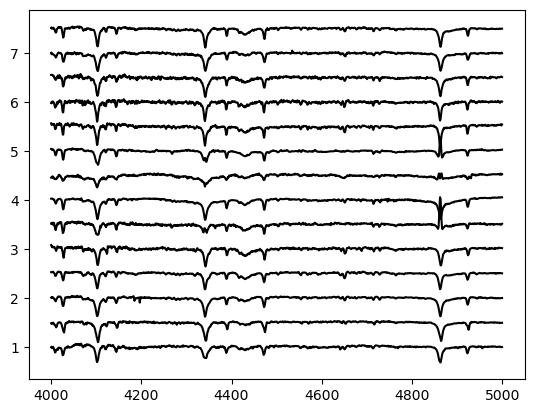

In [868]:
early_B_part1.drop_duplicates(subset="DESIG").reset_index(drop=True).sort_values(by="4471_EW3",ascending=True).apply(lambda row: plot_spec_norm(row["fits_name"],
                                                           [4000,5000],row.name),axis=1,result_type="expand")

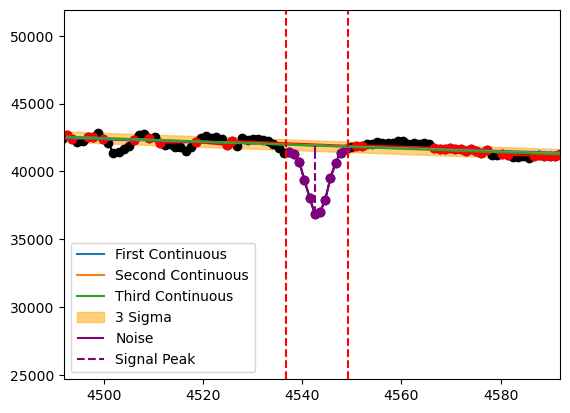

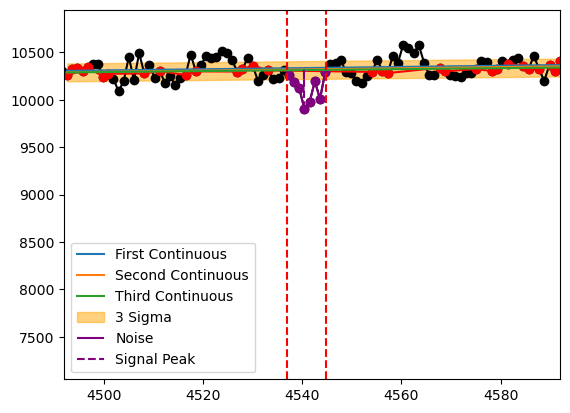

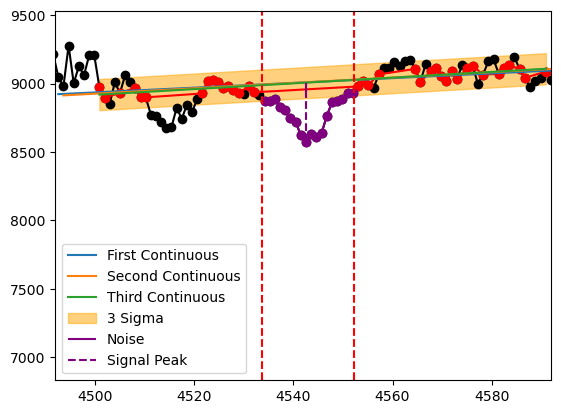

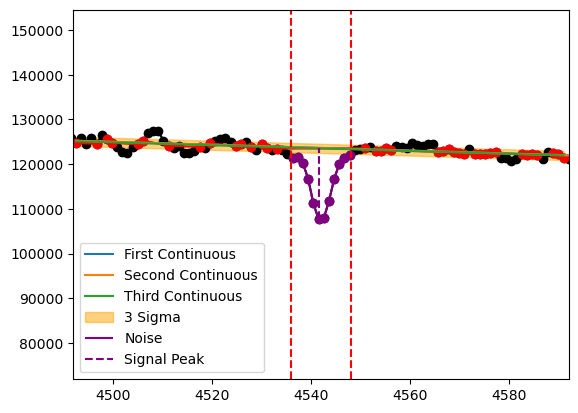

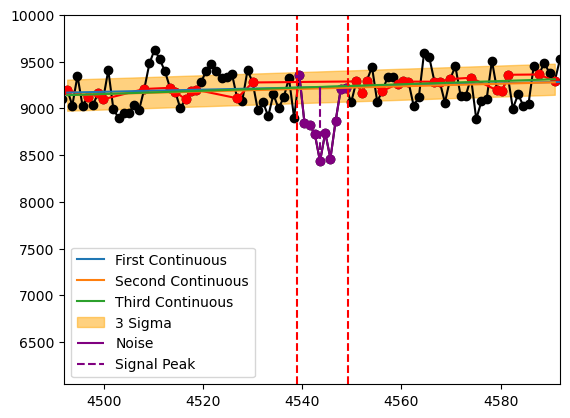

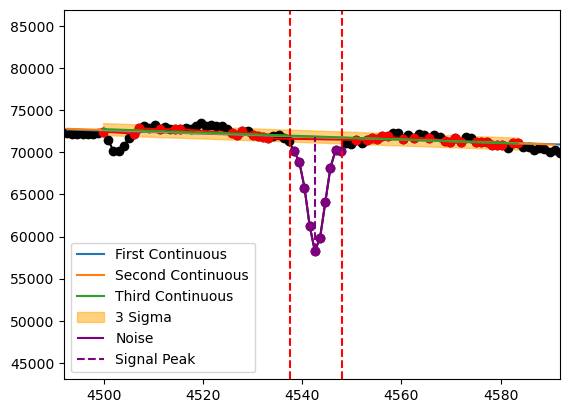

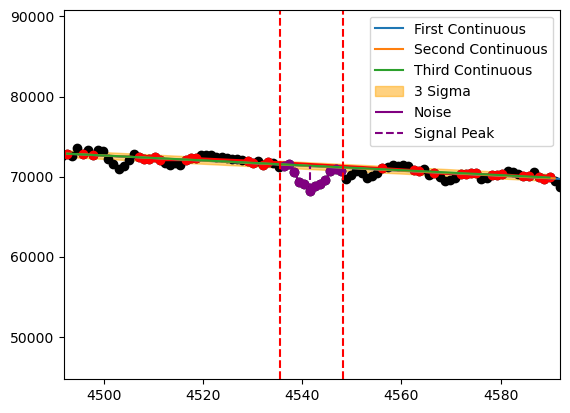

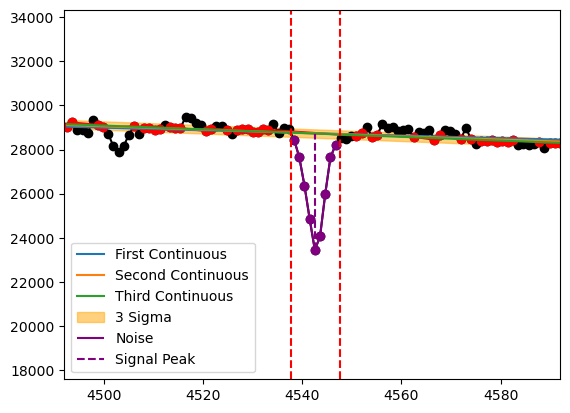

,0,1,2
17,0.668495,2.094345,13.029052
175,0.161571,1.326441,4.366006
227,0.464897,3.097498,3.831356
550,0.690124,2.012569,15.359730
569,0.407089,1.693785,4.794618
573,0.876425,1.750233,19.147061
706,0.239102,2.129557,7.519051
733,0.782161,1.664611,27.650519


In [804]:
O.loc[O["4542_significancia"]>3].apply(lambda row: calculate_EW(row["fits_name"],
                                                           4542,
                                                              1300,
                                                           [4000,5000]),axis=1,result_type="expand")

,SNRG,RA_OBS,DEC_OBS,DESIG,HELIO,HELIO_RV,fits_name,Hgam_mu,Hgam_lambdaEff,SNR,4471_EW3,4471_sigma,4471_significancia,4481_EW3,4481_sigma,4481_significancia,4542_EW3,4542_sigma,4542_significancia
10,248.11,94.986928,23.738152,LAMOST J061956.86+234417.3,True,-11.84411,spec-58456-KII061029N225952V01_sp13-019.fits,4342.723157,4341.583984,196.3992,1.015097,1.995309,12.144105,undetected,undetected,undetected,undetected,undetected,undetected
42,323.59,94.394584,23.264218,LAMOST J061734.70+231551.1,True,4.32183,spec-57391-KP061029N225952V01_sp13-208.fits,4341.703083,4341.648438,256.17804,0.890544,1.783434,10.975306,undetected,undetected,undetected,undetected,undetected,undetected
78,306.18,80.234540,35.073872,LAMOST J052056.28+350425.9,True,21.61280,spec-56687-GAC080N37V1_sp01-206.fits,4341.662174,4341.734375,260.299377,0.727109,1.926744,8.219965,undetected,undetected,undetected,undetected,undetected,undetected
114,132.76,91.390829,23.482611,LAMOST J060533.79+232857.3,True,21.85297,spec-57789-HIP29425K201_sp03-105.fits,4341.893007,4341.585938,123.257179,0.929585,1.755579,11.13499,undetected,undetected,undetected,0.010587,1.326441,1.257295
305,115.13,72.104638,45.225149,LAMOST J044825.11+451330.5,True,22.69154,spec-57054-HD045554N450205V01_sp03-064.fits,4340.985993,4341.588867,100.098053,0.660129,1.990442,8.948425,undetected,undetected,undetected,undetected,undetected,undetected
411,136.68,67.000519,49.657176,LAMOST J042800.12+493925.8,True,25.23023,spec-57798-HD042432N505042V02_sp08-186.fits,4341.928692,4341.644043,112.725449,0.531903,1.70099,6.307141,undetected,undetected,undetected,undetected,undetected,undetected
605,75.36,59.169336,54.367854,LAMOST J035640.64+542204.2,True,-24.16326,spec-57280-HD040922N544943V01_sp10-073.fits,4341.159111,4341.694824,60.368633,0.653078,1.508543,7.823183,undetected,undetected,undetected,-0.00784,1.326441,1.140196
634,117.14,82.092731,39.177131,LAMOST J052822.25+391037.6,True,26.19557,spec-55976-GAC_084N40_V1_sp10-030.fits,4341.303753,4341.674316,101.911789,0.728103,1.710252,12.265564,undetected,undetected,undetected,undetected,undetected,undetected
653,71.99,59.734404,55.019864,LAMOST J035856.25+550111.5,True,-24.06656,spec-57280-HD040922N544943V01_sp14-064.fits,4341.066513,4341.762695,61.751217,0.701095,1.442576,10.764366,undetected,undetected,undetected,undetected,undetected,undetected
727,116.22,36.055197,57.089669,LAMOST J022413.24+570522.8,True,-19.24849,spec-59111-HD023050N553254V01_sp16-154.fits,4341.172292,4341.67041,105.293533,0.8465,1.589889,14.012255,undetected,NaN,NaN,undetected,undetected,undetected


0    None
1    None
2    None
3    None
4    None
5    None
6    None
7    None
8    None
9    None
dtype: object

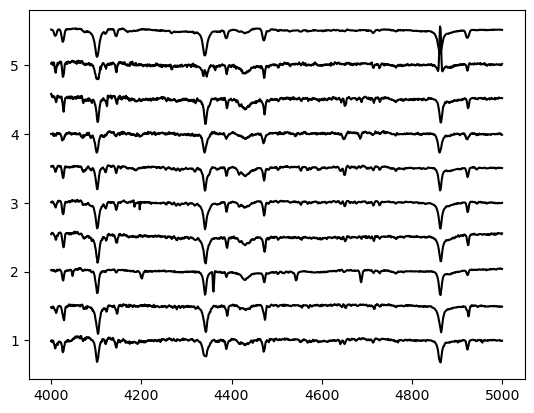

0    None
1    None
2    None
3    None
4    None
5    None
dtype: object

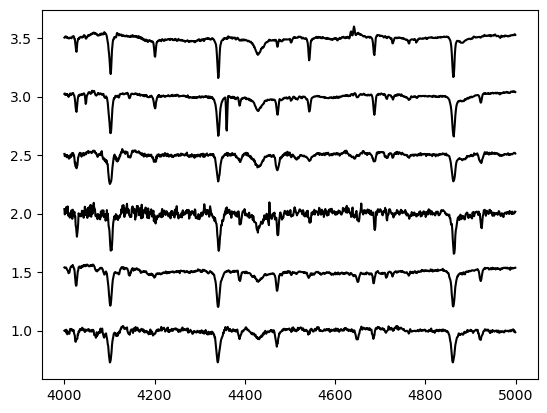

In [828]:
O.loc[O["4542_significancia"]>3].drop_duplicates(subset="DESIG").sort_values(by="4542_EW3",ascending=True).reset_index(drop=True).apply(lambda row: plot_spec_norm(row["fits_name"],
                                                           [4000,5000],row.name),axis=1,result_type="expand")